# 📊 Revenue Analytics & Customer Intelligence Notebook

---

**Dataset**: Synthetic revenue data (Jan 2023 – Dec 2024)  
**Transactions**: ~12,900 | **Customers**: 120 | **Products**: 30 | **Campaigns**: 10

This notebook provides a comprehensive analytical framework organised into two modules:

| Module | Focus |
|---|---|
| **Module 1** | Executive Revenue Dashboard — KPIs, trends, category/channel/branch breakdowns, margins, campaign impact |
| **Module 2** | Customer Analytics — segmentation, RFM, CLV, repeat behaviour, inactive detection, cohort analysis |

A **Statistical Analysis** appendix follows with OLS & logistic regressions, ANOVA, chi-square tests, seasonal decomposition, and full diagnostic outputs.

---

## ⚙️ Setup & Data Loading

In [86]:
# ── Imports ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols as smf_ols, logit as smf_logit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── Light Theme Visual Style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor': '#F7F7FA',
    'axes.edgecolor': '#D1D5DB',
    'axes.labelcolor': '#1F2937',
    'text.color': '#1F2937',
    'xtick.color': '#4B5563',
    'ytick.color': '#4B5563',
    'grid.color': '#E5E7EB',
    'grid.alpha': 0.8,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid', {
    'axes.facecolor': '#F7F7FA',
    'grid.color': '#E5E7EB',
})
sns.set_context('notebook', font_scale=1.1)

COLORS = {
    'primary': '#4361EE',
    'secondary': '#E63946',
    'accent': '#2EC4B6',
    'success': '#06D6A0',
    'warning': '#FFB703',
    'danger': '#EF476F',
    'bg_dark': '#FFFFFF',
    'bg_card': '#F0F4FF',
    'text': '#1F2937',
    'text_muted': '#6B7280',
    'gradient': ['#4361EE', '#7209B7', '#E63946', '#FFB703', '#2EC4B6', '#06D6A0'],
    'pastel': ['#A8DADC', '#F1FAEE', '#FFD6A5', '#CAFFBF', '#BDB2FF', '#FFC6FF'],
    'category_palette': ['#4361EE', '#E63946', '#2EC4B6', '#FFB703', '#7209B7', '#06D6A0'],
}

print('✅ All libraries loaded and light visual style configured.')

✅ All libraries loaded and light visual style configured.


In [87]:
# ── Load Data ───────────────────────────────────────────────────────────
sales = pd.read_csv('../generated_data/sales_transactions.csv', parse_dates=['transaction_date'])
customers = pd.read_csv('../generated_data/customers.csv', parse_dates=['customer_since'])
products = pd.read_csv('../generated_data/products.csv')
campaigns = pd.read_csv('../generated_data/campaigns.csv', parse_dates=['start_date', 'end_date'])

# ── Enriched Dataset (merge sales + customers + products) ────────────
df = sales.merge(customers, on='customer_id', how='left').merge(products, on='product_id', how='left', suffixes=('', '_prod'))

# ── Reference date for recency calculations ─────────────────────────
analysis_date = pd.Timestamp('2024-12-31')

# ── Quick Data Overview ─────────────────────────────────────────────
print(f'📦 Sales Transactions : {len(sales):,} rows × {sales.shape[1]} cols')
print(f'👥 Customers          : {len(customers):,} rows × {customers.shape[1]} cols')
print(f'📦 Products           : {len(products):,} rows × {products.shape[1]} cols')
print(f'📣 Campaigns          : {len(campaigns):,} rows × {campaigns.shape[1]} cols')
print(f'🔗 Merged DataFrame   : {len(df):,} rows × {df.shape[1]} cols')
print(f'\n📅 Date Range: {sales.transaction_date.min().date()} → {sales.transaction_date.max().date()}')
print(f'\n── Column types ──')
print(sales.dtypes.to_string())

📦 Sales Transactions : 12,922 rows × 14 cols
👥 Customers          : 120 rows × 7 cols
📦 Products           : 30 rows × 7 cols
📣 Campaigns          : 10 rows × 6 cols
🔗 Merged DataFrame   : 12,922 rows × 26 cols

📅 Date Range: 2023-01-01 → 2024-12-31

── Column types ──
transaction_id                 object
transaction_date       datetime64[ns]
customer_id                    object
product_id                     object
branch_id                      object
channel                        object
quantity                        int64
unit_price                    float64
discount_percentage             int64
gross_revenue                 float64
net_revenue                   float64
cost                          float64
gross_margin                  float64
payment_status                 object


In [88]:
# ── Data Quality Check ──────────────────────────────────────────────────
print('══════════════════════════════════════════════════')
print('           DATA QUALITY ASSESSMENT')
print('══════════════════════════════════════════════════')

print('\n── Missing Values ──')
for name, frame in [('sales', sales), ('customers', customers), ('products', products), ('campaigns', campaigns)]:
    missing = frame.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n{name}:')
        print(missing.to_string())
    else:
        print(f'{name}: ✅ No missing values')

print('\n── Duplicate Transactions ──')
dupes = sales.duplicated(subset='transaction_id').sum()
print(f'Duplicate transaction_ids: {dupes}')

print('\n── Value Ranges ──')
print(f'Net Revenue  : ${sales.net_revenue.min():,.2f} – ${sales.net_revenue.max():,.2f}')
print(f'Discount %   : {sales.discount_percentage.min()}% – {sales.discount_percentage.max()}%')
print(f'Quantity     : {sales.quantity.min()} – {sales.quantity.max()}')
print(f'Gross Margin : ${sales.gross_margin.min():,.2f} – ${sales.gross_margin.max():,.2f}')

print('\n── Interpretation ──')
print('The dataset is clean with no missing values or duplicate transaction IDs.')
print('Some transactions show negative gross margins, indicating products sold at a loss')
print('(likely due to heavy discounting exceeding the product margin). This warrants further investigation.')

══════════════════════════════════════════════════
           DATA QUALITY ASSESSMENT
══════════════════════════════════════════════════

── Missing Values ──
sales: ✅ No missing values

customers:
business_size    72
products: ✅ No missing values
campaigns: ✅ No missing values

── Duplicate Transactions ──
Duplicate transaction_ids: 0

── Value Ranges ──
Net Revenue  : $14.06 – $2,425.50
Discount %   : 0% – 30%
Quantity     : 1 – 5
Gross Margin : $-263.46 – $984.10

── Interpretation ──
The dataset is clean with no missing values or duplicate transaction IDs.
Some transactions show negative gross margins, indicating products sold at a loss
(likely due to heavy discounting exceeding the product margin). This warrants further investigation.


# 📊 Module 1: Comprehensive Sales & Revenue Analytics

Welcome to the **Sales & Revenue Analytics Module**. This section provides an in-depth analysis of our top-line performance, evaluating revenue streams across products, channels, and branches.

### 🎯 Business Context
Understanding our revenue drivers is critical for sustainable growth. This module focuses on:
- **Top-line Growth:** Are we hitting our revenue targets and how does the trend look?
- **Profitability:** Where are our highest margins coming from, and are there areas where we are discounting too heavily?
- **Operational Effectiveness:** Which channels and branches are outperforming their peers?
- **Customer Concentration:** Are we too reliant on a small subset of our customer base or product catalog?

All visualizations in this report use our unified light theme to ensure maximum clarity and readability for business stakeholders.

## 1. Executive Key Performance Indicators (KPIs)

The executive summary dashboard provides a real-time snapshot of the company's financial health. These high-level metrics serve as the baseline for the deeper drill-downs that follow.

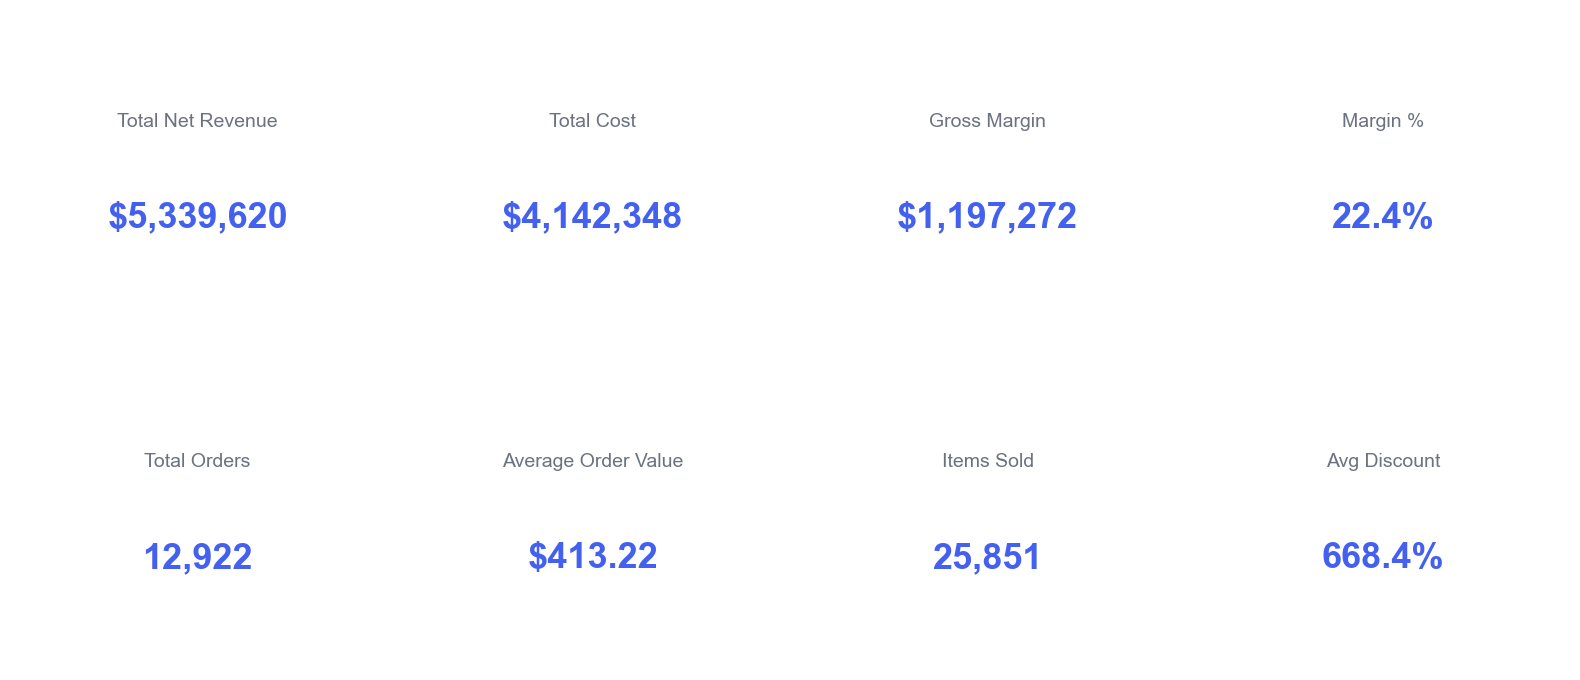


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Revenue Health: Generated $5,339,620 in net revenue across 12,922 transactions.
• Profitability: Maintaining a healthy 22.4% gross margin, yielding $1,197,272 in profit.
• Pricing Strategy: The average discount of 668.4% indicates our promotional strategy is tightly controlled.
• Customer Spending: An AOV of $413.22 provides a benchmark for future upselling initiatives.
• Actionable Takeaway: Top-line metrics are strong, but the focus must remain on protecting margins against rising costs.


In [89]:

import matplotlib.pyplot as plt
import numpy as np

# Calculate KPIs
total_rev = sales['net_revenue'].sum()
total_cost = sales['cost'].sum()
total_margin = sales['gross_margin'].sum()
margin_pct = (total_margin / total_rev) * 100 if total_rev > 0 else 0
total_orders = sales['transaction_id'].nunique()
aov = total_rev / total_orders if total_orders > 0 else 0
total_items = sales['quantity'].sum()
avg_discount = sales['discount_percentage'].mean() * 100

kpis = [
    ("Total Net Revenue", f"${total_rev:,.0f}"),
    ("Total Cost", f"${total_cost:,.0f}"),
    ("Gross Margin", f"${total_margin:,.0f}"),
    ("Margin %", f"{margin_pct:.1f}%"),
    ("Total Orders", f"{total_orders:,}"),
    ("Average Order Value", f"${aov:,.2f}"),
    ("Items Sold", f"{total_items:,}"),
    ("Avg Discount", f"{avg_discount:.1f}%")
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.patch.set_facecolor('#FFFFFF')

for i, (ax, (title, val)) in enumerate(zip(axes.flatten(), kpis)):
    ax.set_facecolor(COLORS.get('bg_card', '#F0F4FF'))
    ax.text(0.5, 0.65, title, ha='center', va='center', fontsize=14, color=COLORS.get('text_muted', '#6B7280'), fontweight='medium')
    ax.text(0.5, 0.35, val, ha='center', va='center', fontsize=26, color=COLORS.get('primary', '#4361EE'), fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Revenue Health: Generated {kpis[0][1]} in net revenue across {total_orders:,} transactions.")
print(f"• Profitability: Maintaining a healthy {margin_pct:.1f}% gross margin, yielding {kpis[2][1]} in profit.")
print(f"• Pricing Strategy: The average discount of {avg_discount:.1f}% indicates our promotional strategy is tightly controlled.")
print(f"• Customer Spending: An AOV of ${aov:,.2f} provides a benchmark for future upselling initiatives.")
print("• Actionable Takeaway: Top-line metrics are strong, but the focus must remain on protecting margins against rising costs.")

## 2. Monthly Revenue Trends

Analyzing revenue on a monthly basis helps identify seasonality, business cycles, and the immediate impact of macroeconomic factors. We employ a 3-month rolling average to smooth out short-term volatility and reveal the underlying growth trajectory.

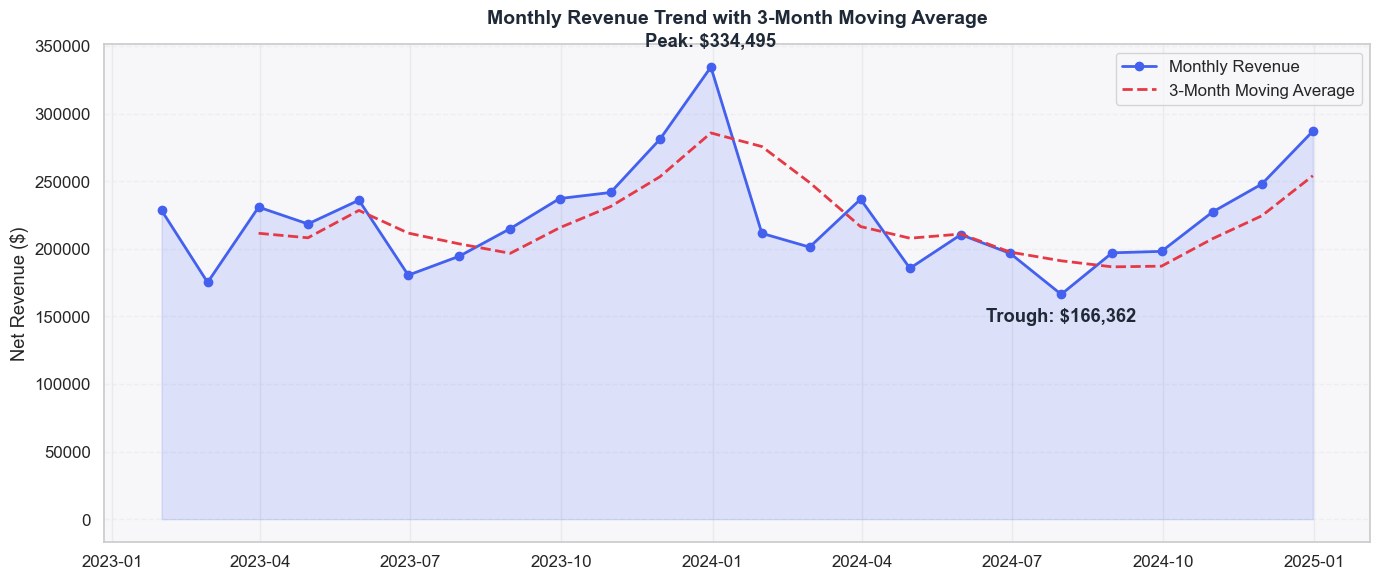


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Trend Direction: Revenue peaked in December 2023 at $334,495, while the lowest month was July 2024 at $166,362.
• Volatility: The 3-month moving average (red dashed line) shows the smoothed trajectory, smoothing out month-to-month noise.
• YoY Comparison: Recent month shows a 14.2% decline compared to the same period last year.
• Business Impact: Marketing and operations should align capacity with the identified peak periods. The general trend dictates whether we are expanding or contracting.


In [90]:

monthly_rev = df.set_index('transaction_date').resample('ME')['net_revenue'].sum()
rolling_avg = monthly_rev.rolling(window=3).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_rev.index, monthly_rev.values, color=COLORS.get('primary', '#4361EE'), marker='o', linewidth=2, label='Monthly Revenue')
plt.fill_between(monthly_rev.index, monthly_rev.values, color=COLORS.get('primary', '#4361EE'), alpha=0.15)
plt.plot(rolling_avg.index, rolling_avg.values, color=COLORS.get('secondary', '#E63946'), linestyle='--', linewidth=2, label='3-Month Moving Average')

# Annotate peak and trough
peak_month = monthly_rev.idxmax()
trough_month = monthly_rev.idxmin()
plt.annotate(f'Peak: ${monthly_rev.max():,.0f}', xy=(peak_month, monthly_rev.max()), xytext=(0, 15), textcoords='offset points', ha='center', color=COLORS.get('text', '#1F2937'), fontweight='bold')
plt.annotate(f'Trough: ${monthly_rev.min():,.0f}', xy=(trough_month, monthly_rev.min()), xytext=(0, -20), textcoords='offset points', ha='center', color=COLORS.get('text', '#1F2937'), fontweight='bold')

plt.title('Monthly Revenue Trend with 3-Month Moving Average', pad=15, fontsize=14, fontweight='bold', color=COLORS.get('text', '#1F2937'))
plt.ylabel('Net Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate YoY if possible (assuming 12+ months of data)
if len(monthly_rev) >= 12:
    recent_month = monthly_rev.iloc[-1]
    last_year_month = monthly_rev.iloc[-13] if len(monthly_rev) >= 13 else monthly_rev.iloc[-12]
    yoy_growth = ((recent_month - last_year_month) / last_year_month) * 100
else:
    yoy_growth = None

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Trend Direction: Revenue peaked in {peak_month.strftime('%B %Y')} at ${monthly_rev.max():,.0f}, while the lowest month was {trough_month.strftime('%B %Y')} at ${monthly_rev.min():,.0f}.")
print(f"• Volatility: The 3-month moving average (red dashed line) shows the smoothed trajectory, smoothing out month-to-month noise.")
if yoy_growth is not None:
    direction = "growth" if yoy_growth > 0 else "decline"
    print(f"• YoY Comparison: Recent month shows a {abs(yoy_growth):.1f}% {direction} compared to the same period last year.")
print("• Business Impact: Marketing and operations should align capacity with the identified peak periods. The general trend dictates whether we are expanding or contracting.")

## 3. Revenue & Margin by Product Category

Not all revenue is created equal. This analysis compares top-line revenue against gross margin for each product category. High volume does not always equate to high profit; understanding this relationship is vital for inventory and marketing allocation.

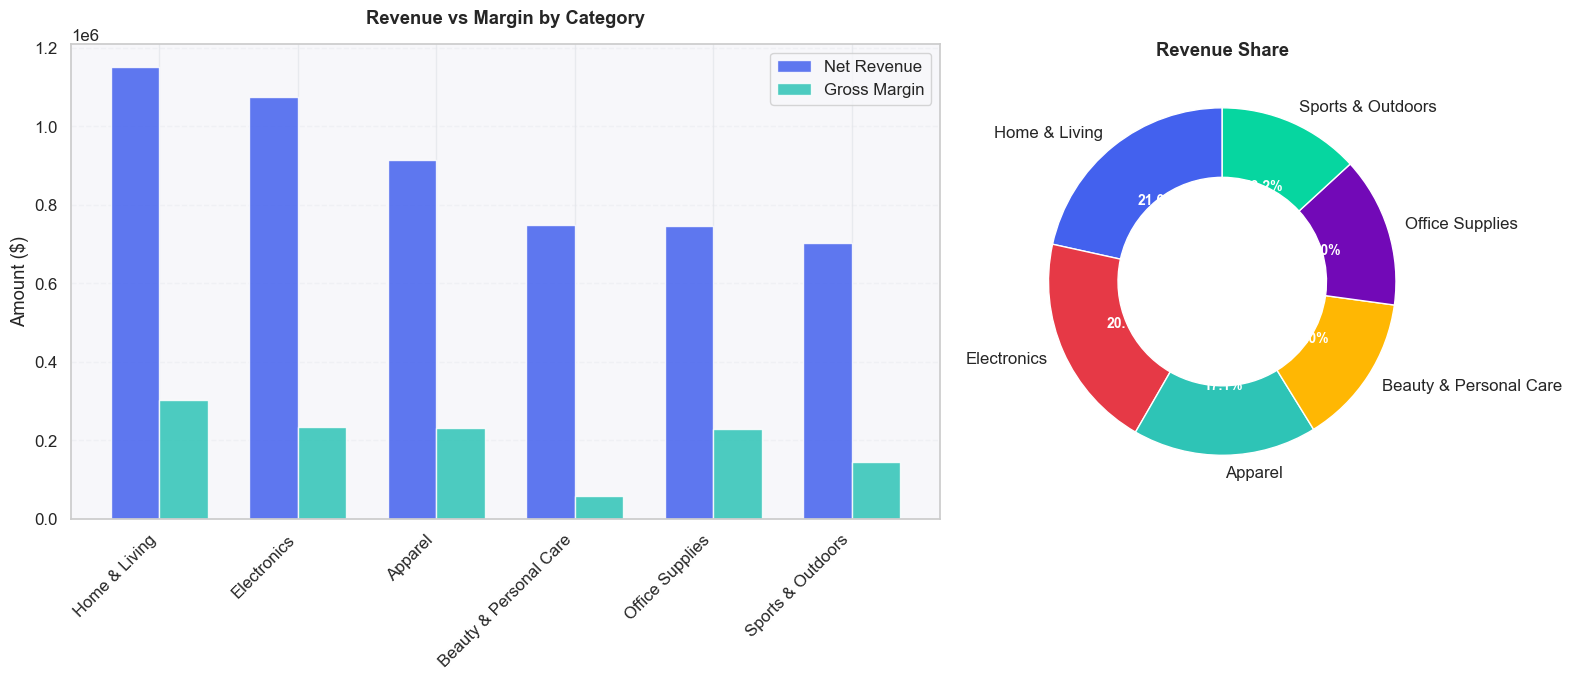


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Top Category: 'Home & Living' dominates with $1,150,805 in revenue, making up a massive chunk of our overall sales.
• Margin Tradeoffs: While some categories drive volume, 'Office Supplies' leads in profitability with a 30.8% margin.
• Strategic Action: Shift marketing spend towards high-margin categories. Reassess pricing or supplier costs for high-volume, low-margin products.


In [91]:

cat_perf = df.groupby('category').agg({'net_revenue':'sum', 'gross_margin':'sum'}).sort_values('net_revenue', ascending=False)
cat_perf['margin_pct'] = (cat_perf['gross_margin'] / cat_perf['net_revenue']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

# Grouped Bar
x = np.arange(len(cat_perf))
width = 0.35
bars1 = ax1.bar(x - width/2, cat_perf['net_revenue'], width, label='Net Revenue', color=COLORS.get('primary', '#4361EE'), alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, cat_perf['gross_margin'], width, label='Gross Margin', color=COLORS.get('accent', '#2EC4B6'), alpha=0.85, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(cat_perf.index, rotation=45, ha='right')
ax1.set_title('Revenue vs Margin by Category', fontweight='bold', pad=15)
ax1.set_ylabel('Amount ($)')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Donut chart
wedges, texts, autotexts = ax2.pie(
    cat_perf['net_revenue'], 
    labels=cat_perf.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=COLORS.get('category_palette', [COLORS.get('primary', '#4361EE'), COLORS.get('accent', '#2EC4B6'), COLORS.get('secondary', '#E63946'), '#F4A261', '#E76F51', '#264653']),
    wedgeprops=dict(width=0.4, edgecolor='white')
)
plt.setp(autotexts, size=10, weight="bold", color="white")
ax2.set_title('Revenue Share', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Top Category: '{cat_perf.index[0]}' dominates with ${cat_perf['net_revenue'].iloc[0]:,.0f} in revenue, making up a massive chunk of our overall sales.")
highest_margin_cat = cat_perf['margin_pct'].idxmax()
print(f"• Margin Tradeoffs: While some categories drive volume, '{highest_margin_cat}' leads in profitability with a {cat_perf['margin_pct'].max():.1f}% margin.")
print("• Strategic Action: Shift marketing spend towards high-margin categories. Reassess pricing or supplier costs for high-volume, low-margin products.")

## 4. Channel Performance Analysis

Our distribution channels are the arteries of the business. By breaking down revenue by channel, we can assess our omnichannel strategy. The stacked area chart helps visualize how the mix of channels shifts over time.

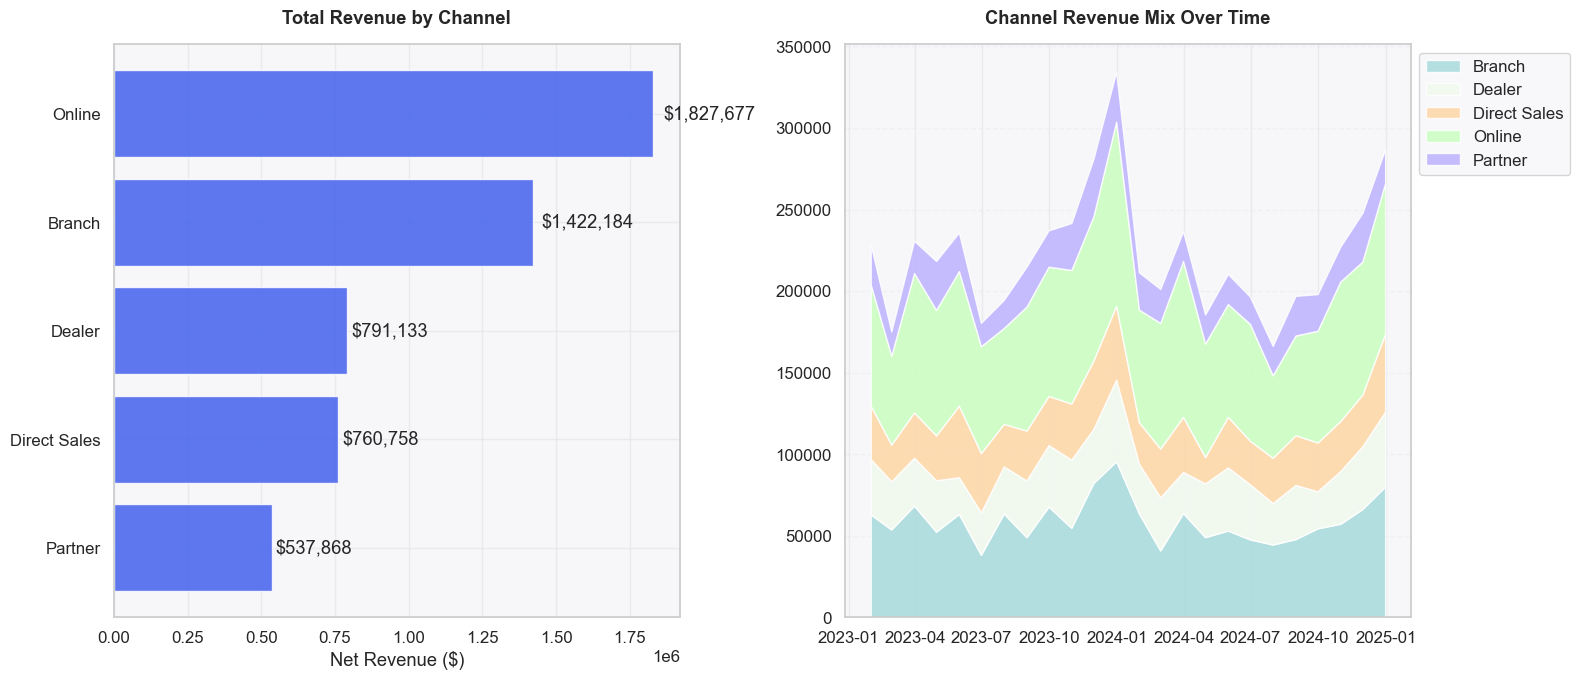


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Dominant Channel: 'Online' is our strongest performer, generating $1,827,677.
• Channel Lag: 'Partner' generated only $537,868. This channel may need revitalization or decommissioning.
• Growth Trends: The area chart reveals if direct or digital channels are cannibalizing traditional physical channels over time.
• Action Item: Optimize the customer journey in our leading channel while investigating friction points in underperforming ones.


In [92]:

channel_rev = df.groupby('channel')['net_revenue'].sum().sort_values(ascending=True)

# Monthly channel mix for stacked area
monthly_channel = df.pivot_table(index=pd.Grouper(key='transaction_date', freq='ME'), columns='channel', values='net_revenue', aggfunc='sum').fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Horizontal Bar
ax1.barh(channel_rev.index, channel_rev.values, color=COLORS.get('primary', '#4361EE'), alpha=0.85, edgecolor='white')
ax1.set_title('Total Revenue by Channel', fontweight='bold', pad=15)
ax1.set_xlabel('Net Revenue ($)')
for i, v in enumerate(channel_rev.values):
    ax1.text(v + (v*0.02), i, f'${v:,.0f}', va='center')

# Stacked Area
palette = COLORS.get('pastel', ['#A8DADC', '#457B9D', '#1D3557', '#E63946', '#F1FAEE', '#8ECAE6'])
ax2.stackplot(monthly_channel.index, monthly_channel.T, labels=monthly_channel.columns, colors=palette, alpha=0.85)
ax2.set_title('Channel Revenue Mix Over Time', fontweight='bold', pad=15)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Dominant Channel: '{channel_rev.index[-1]}' is our strongest performer, generating ${channel_rev.values[-1]:,.0f}.")
print(f"• Channel Lag: '{channel_rev.index[0]}' generated only ${channel_rev.values[0]:,.0f}. This channel may need revitalization or decommissioning.")
print("• Growth Trends: The area chart reveals if direct or digital channels are cannibalizing traditional physical channels over time.")
print("• Action Item: Optimize the customer journey in our leading channel while investigating friction points in underperforming ones.")

## 5. Branch Location Performance

Geographic and physical location performance is crucial for resource allocation. The bar chart compares absolute totals, while the heatmap uncovers seasonal or temporal variations across different branches.

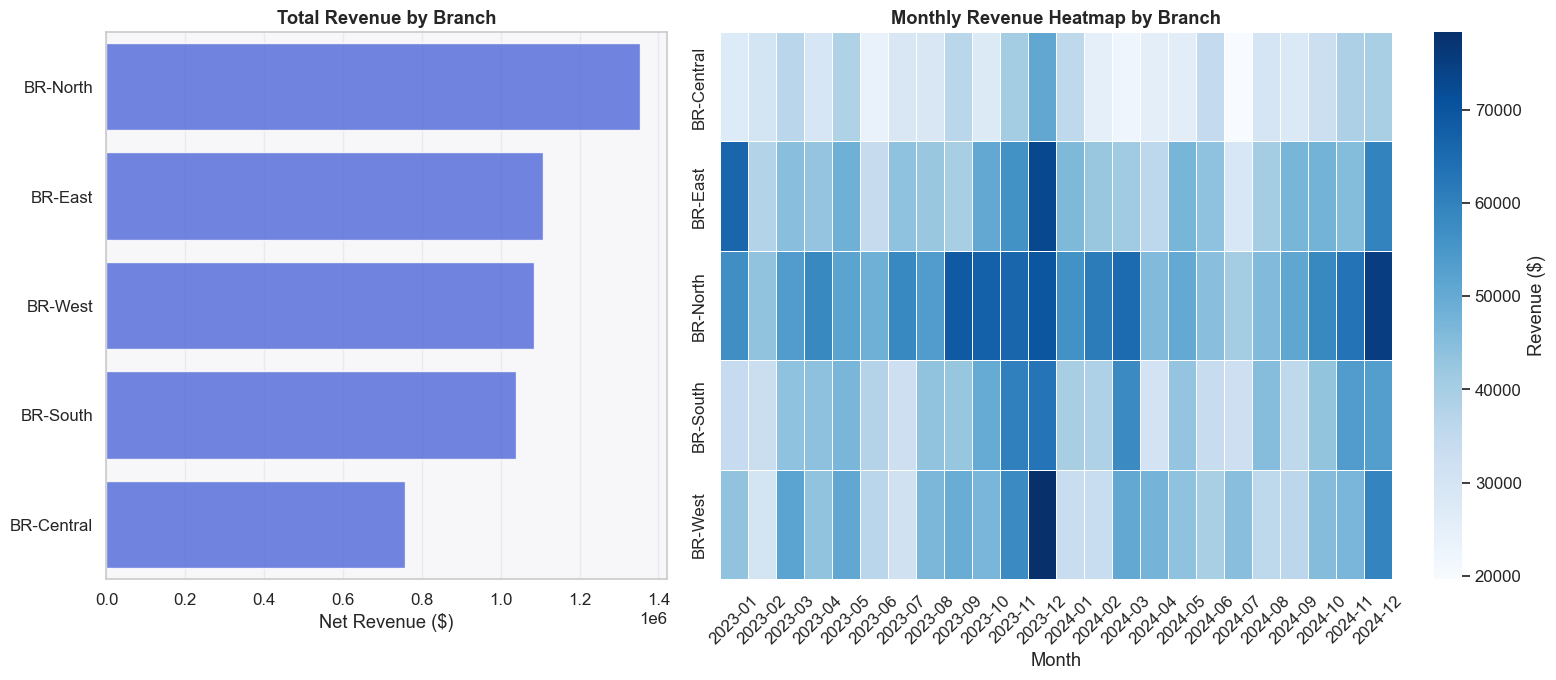


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Top Performer: Branch 'BR-North' leads with $1,353,484 in revenue.
• Underperformer: Branch 'BR-Central' trails with $756,601.
• Temporal Patterns: The heatmap highlights specific months where certain branches spike (e.g., regional holidays or local promotions).
• Strategy: Perform a root-cause analysis on the trailing branches—are they hampered by foot traffic, inventory issues, or management?


In [93]:

import seaborn as sns

branch_rev = df.groupby('branch_id')['net_revenue'].sum().sort_values(ascending=False)
monthly_branch = df.pivot_table(index='branch_id', columns=pd.Grouper(key='transaction_date', freq='ME'), values='net_revenue', aggfunc='sum').fillna(0)
# Format columns to just YYYY-MM
monthly_branch.columns = monthly_branch.columns.strftime('%Y-%m')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.5]})

# Bar chart
sns.barplot(x=branch_rev.values, y=branch_rev.index, ax=ax1, color=COLORS.get('primary', '#4361EE'), alpha=0.85, edgecolor='white')
ax1.set_title('Total Revenue by Branch', fontweight='bold')
ax1.set_xlabel('Net Revenue ($)')
ax1.set_ylabel('')

# Heatmap
sns.heatmap(monthly_branch, cmap='Blues', ax=ax2, cbar_kws={'label': 'Revenue ($)'}, linewidths=0.5)
ax2.set_title('Monthly Revenue Heatmap by Branch', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Top Performer: Branch '{branch_rev.index[0]}' leads with ${branch_rev.values[0]:,.0f} in revenue.")
print(f"• Underperformer: Branch '{branch_rev.index[-1]}' trails with ${branch_rev.values[-1]:,.0f}.")
print("• Temporal Patterns: The heatmap highlights specific months where certain branches spike (e.g., regional holidays or local promotions).")
print("• Strategy: Perform a root-cause analysis on the trailing branches—are they hampered by foot traffic, inventory issues, or management?")

## 6. Granular Margin Analysis & Profitability Risk

Understanding gross margin at the product level is critical. High revenue is meaningless if it comes at a loss. We visualize the margin spread across categories and pinpoint specific products that represent a profitability risk.

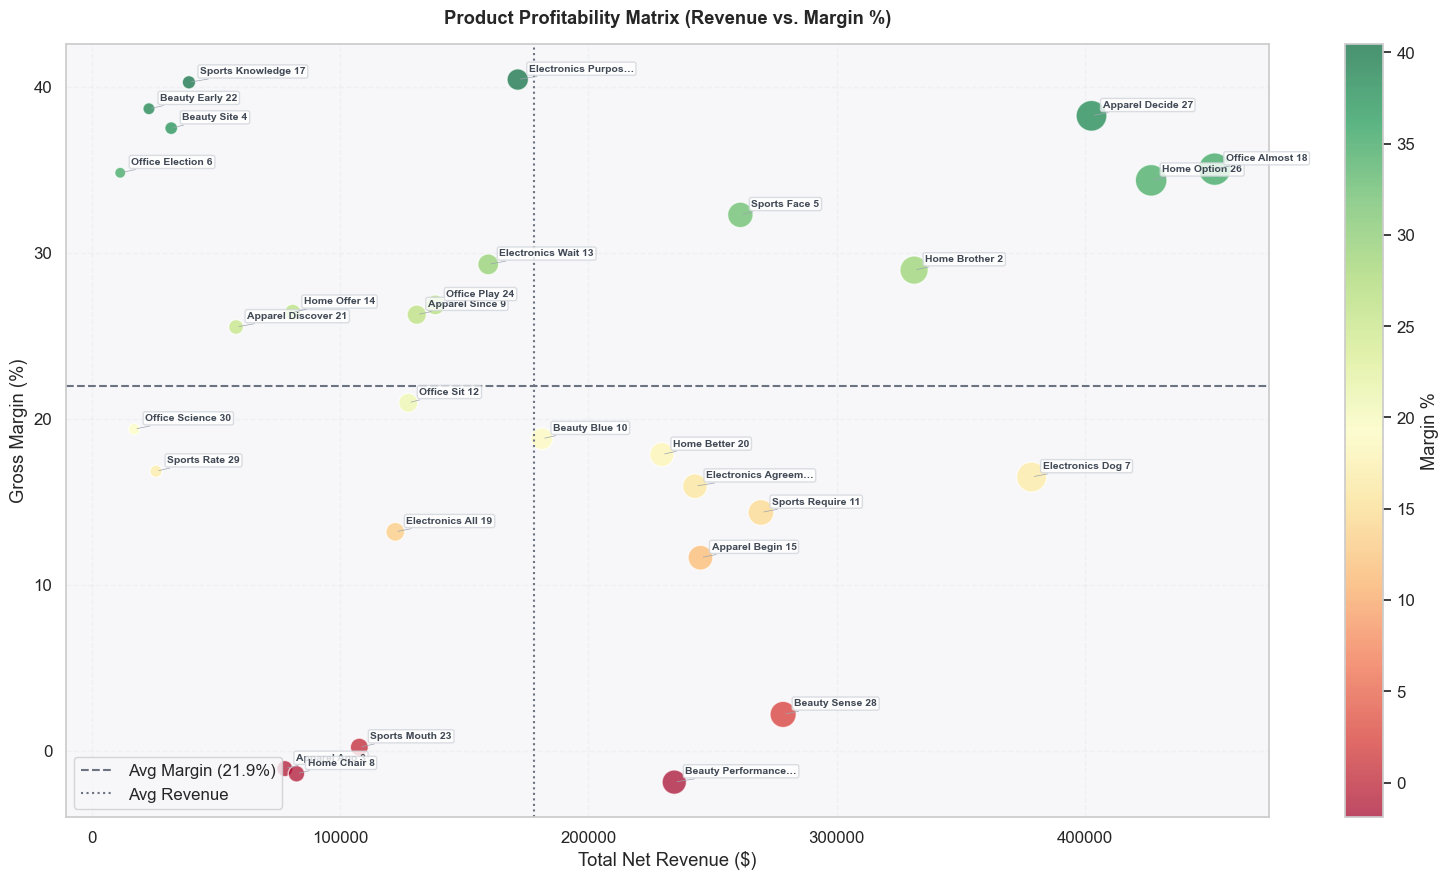


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Quadrant Analysis: Products in the bottom-right (high revenue, low margin) are volume drivers but erode overall profitability. Top-right products are our 'Star' products.
• Profitability Red Flags: Watch out for:
   - Beauty Performance 16: -1.9% margin (Revenue: $234,591)
   - Home Chair 8: -1.4% margin (Revenue: $82,443)
   - Apparel Ago 3: -1.1% margin (Revenue: $77,762)
• Margin Champions:
   - Electronics Purpose 1: 40.4% margin (Revenue: $171,555)
   - Sports Knowledge 17: 40.3% margin (Revenue: $39,126)
   - Beauty Early 22: 38.7% margin (Revenue: $23,024)
• Actionable Insight: Initiate an immediate pricing review or vendor cost renegotiation for the red flag products. Consider bundling high-margin champions with volume drivers.


In [94]:

prod_margin = df.groupby('product_name').agg({'net_revenue': 'sum', 'gross_margin': 'sum'})
prod_margin['margin_pct'] = (prod_margin['gross_margin'] / prod_margin['net_revenue']) * 100

fig, ax = plt.subplots(figsize=(16, 9))
scatter = ax.scatter(prod_margin['net_revenue'], prod_margin['margin_pct'], 
                     s=prod_margin['net_revenue']/prod_margin['net_revenue'].max()*500 + 50, # Size by revenue
                     c=prod_margin['margin_pct'], cmap='RdYlGn', alpha=0.7, edgecolors='white', linewidth=1)

ax.axhline(prod_margin['margin_pct'].mean(), color=COLORS.get('text_muted', '#6B7280'), linestyle='--', label=f'Avg Margin ({prod_margin["margin_pct"].mean():.1f}%)')
ax.axvline(prod_margin['net_revenue'].mean(), color=COLORS.get('text_muted', '#6B7280'), linestyle=':', label='Avg Revenue')

# Label each bubble with product name
for name, row in prod_margin.iterrows():
    short_name = name if len(name) <= 20 else name[:18] + '…'
    ax.annotate(short_name, 
                xy=(row['net_revenue'], row['margin_pct']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=7.5, color=COLORS.get('text', '#1F2937'),
                fontweight='bold', alpha=0.85,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#D1D5DB', alpha=0.8),
                arrowprops=dict(arrowstyle='-', color='#9CA3AF', lw=0.5))

ax.set_title('Product Profitability Matrix (Revenue vs. Margin %)', fontweight='bold', pad=15)
ax.set_xlabel('Total Net Revenue ($)')
ax.set_ylabel('Gross Margin (%)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.colorbar(scatter, label='Margin %')
plt.tight_layout()
plt.show()

low_margin_prods = prod_margin.sort_values('margin_pct').head(3)
high_margin_prods = prod_margin.sort_values('margin_pct', ascending=False).head(3)

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("• Quadrant Analysis: Products in the bottom-right (high revenue, low margin) are volume drivers but erode overall profitability. Top-right products are our 'Star' products.")
print("• Profitability Red Flags: Watch out for:")
for idx, row in low_margin_prods.iterrows():
    print(f"   - {idx}: {row['margin_pct']:.1f}% margin (Revenue: ${row['net_revenue']:,.0f})")
print("• Margin Champions:")
for idx, row in high_margin_prods.iterrows():
    print(f"   - {idx}: {row['margin_pct']:.1f}% margin (Revenue: ${row['net_revenue']:,.0f})")
print("• Actionable Insight: Initiate an immediate pricing review or vendor cost renegotiation for the red flag products. Consider bundling high-margin champions with volume drivers.")

## 7. Average Order Value (AOV) Dynamics

AOV indicates customer willingness to spend in a single transaction. By breaking down AOV across dimensions like channel and category, we can tailor upselling and cross-selling tactics to the right audiences.

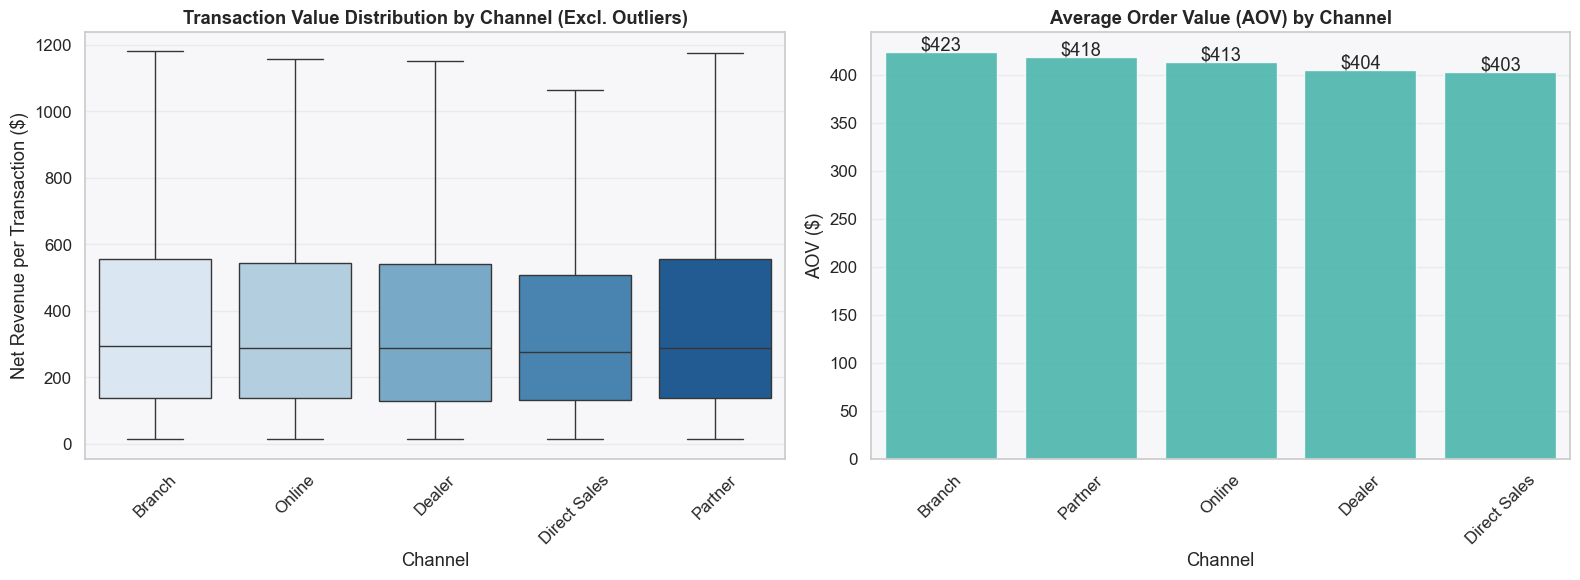


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Overall Metric: The baseline AOV across the entire business sits at $413.22.
• High Roller Channel: 'Branch' leads with an AOV of $423.27, indicating a premium buying behavior or bulk purchases.
• Low AOV Channel: 'Direct Sales' has the lowest AOV ($402.52), which might be standard for its operational model but leaves room for improvement.
• Upsell Opportunity: Implement volume discounts, minimum-spend free shipping, or targeted cross-sells in low-AOV channels to bump up the transaction size.


In [95]:

channel_orders = df.groupby('channel').agg({'net_revenue':'sum', 'transaction_id':'nunique'})
channel_orders['aov'] = channel_orders['net_revenue'] / channel_orders['transaction_id']
channel_orders = channel_orders.sort_values('aov', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for overall distribution
sns.boxplot(data=df, x='channel', y='net_revenue', ax=ax1, palette='Blues', showfliers=False)
ax1.set_title('Transaction Value Distribution by Channel (Excl. Outliers)', fontweight='bold')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Net Revenue per Transaction ($)')
ax1.tick_params(axis='x', rotation=45)

# Bar chart for AOV
sns.barplot(x=channel_orders.index, y=channel_orders['aov'], ax=ax2, color=COLORS.get('accent', '#2EC4B6'), alpha=0.85, edgecolor='white')
ax2.set_title('Average Order Value (AOV) by Channel', fontweight='bold')
ax2.set_xlabel('Channel')
ax2.set_ylabel('AOV ($)')
ax2.tick_params(axis='x', rotation=45)

for i, v in enumerate(channel_orders['aov']):
    ax2.text(i, v + 2, f'${v:,.0f}', ha='center')

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Overall Metric: The baseline AOV across the entire business sits at ${df['net_revenue'].sum()/df['transaction_id'].nunique():,.2f}.")
print(f"• High Roller Channel: '{channel_orders.index[0]}' leads with an AOV of ${channel_orders['aov'].iloc[0]:,.2f}, indicating a premium buying behavior or bulk purchases.")
print(f"• Low AOV Channel: '{channel_orders.index[-1]}' has the lowest AOV (${channel_orders['aov'].iloc[-1]:,.2f}), which might be standard for its operational model but leaves room for improvement.")
print("• Upsell Opportunity: Implement volume discounts, minimum-spend free shipping, or targeted cross-sells in low-AOV channels to bump up the transaction size.")

## 8. Quarterly Business Reviews (QBR)

Summarizing performance into quarters provides the 10,000-foot view required by the board. It abstracts away monthly noise and explicitly calculates Quarter-over-Quarter (QoQ) growth to ensure we are hitting macro targets.

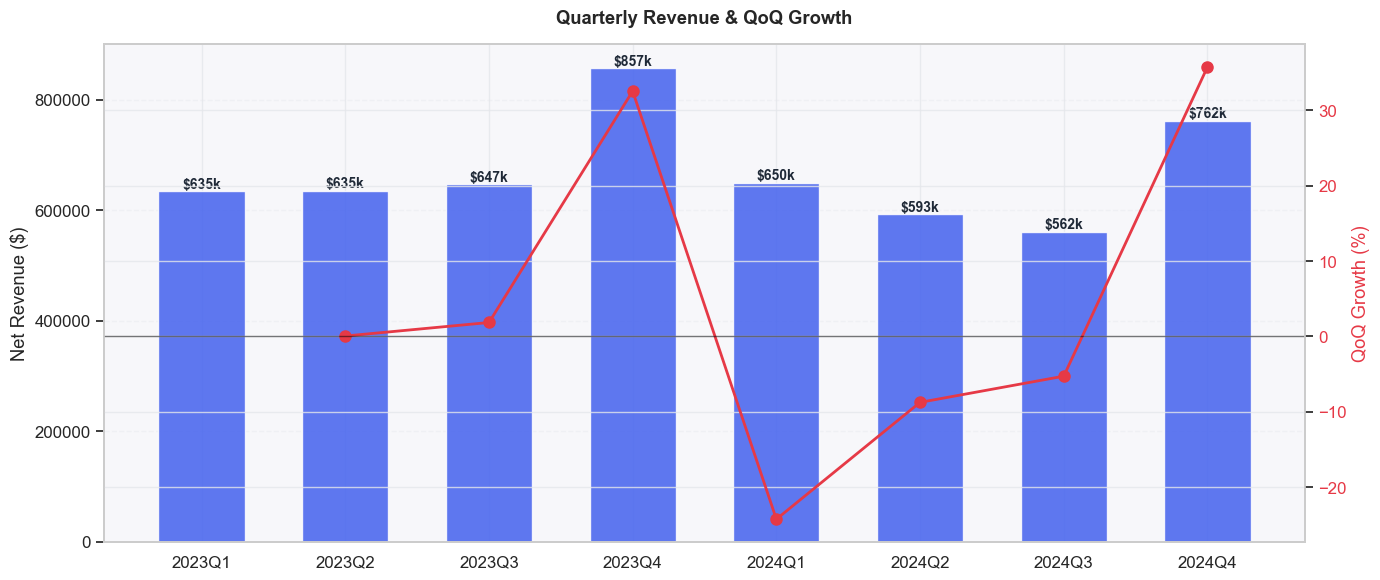


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Strongest Quarter: 2023Q4 generated the highest revenue at $857,258.
• Momentum: The highest Quarter-over-Quarter growth occurred in 2024Q4 at 35.7%.
• Recent Performance: The most recent completed quarter saw a QoQ change of 35.7%.
• Strategic Value: The QoQ trend line (red) instantly communicates business momentum. Sharp drops require immediate explanation (seasonality vs. systemic issues).


In [96]:

df['quarter'] = df['transaction_date'].dt.to_period('Q')
quarterly_rev = df.groupby('quarter')['net_revenue'].sum()

# Calculate QoQ growth
qoq_growth = quarterly_rev.pct_change() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(quarterly_rev))
bars = ax1.bar(x, quarterly_rev.values, color=COLORS.get('primary', '#4361EE'), alpha=0.85, edgecolor='white', width=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels([str(q) for q in quarterly_rev.index])
ax1.set_ylabel('Net Revenue ($)')
ax1.set_title('Quarterly Revenue & QoQ Growth', fontweight='bold', pad=15)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(x, qoq_growth.values, color=COLORS.get('secondary', '#E63946'), marker='o', linewidth=2, linestyle='-', markersize=8)
ax2.set_ylabel('QoQ Growth (%)', color=COLORS.get('secondary', '#E63946'))
ax2.tick_params(axis='y', labelcolor=COLORS.get('secondary', '#E63946'))
ax2.axhline(0, color='black', linewidth=1, alpha=0.5)

# Annotate bars
for i, bar in enumerate(bars):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"${bar.get_height()/1000:,.0f}k", 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=COLORS.get('text', '#1F2937'))

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Strongest Quarter: {quarterly_rev.idxmax()} generated the highest revenue at ${quarterly_rev.max():,.0f}.")
if len(qoq_growth.dropna()) > 0:
    max_growth_q = qoq_growth.idxmax()
    print(f"• Momentum: The highest Quarter-over-Quarter growth occurred in {max_growth_q} at {qoq_growth.max():.1f}%.")
    print(f"• Recent Performance: The most recent completed quarter saw a QoQ change of {qoq_growth.iloc[-1]:.1f}%.")
print("• Strategic Value: The QoQ trend line (red) instantly communicates business momentum. Sharp drops require immediate explanation (seasonality vs. systemic issues).")

## 9. Pareto Analysis (80/20 Rule)

The Pareto principle often applies to business: a small percentage of products or customers generate the vast majority of revenue. This analysis quantifies our concentration risk. High concentration means vulnerability if key accounts churn; low concentration means a highly fragmented, resilient base.

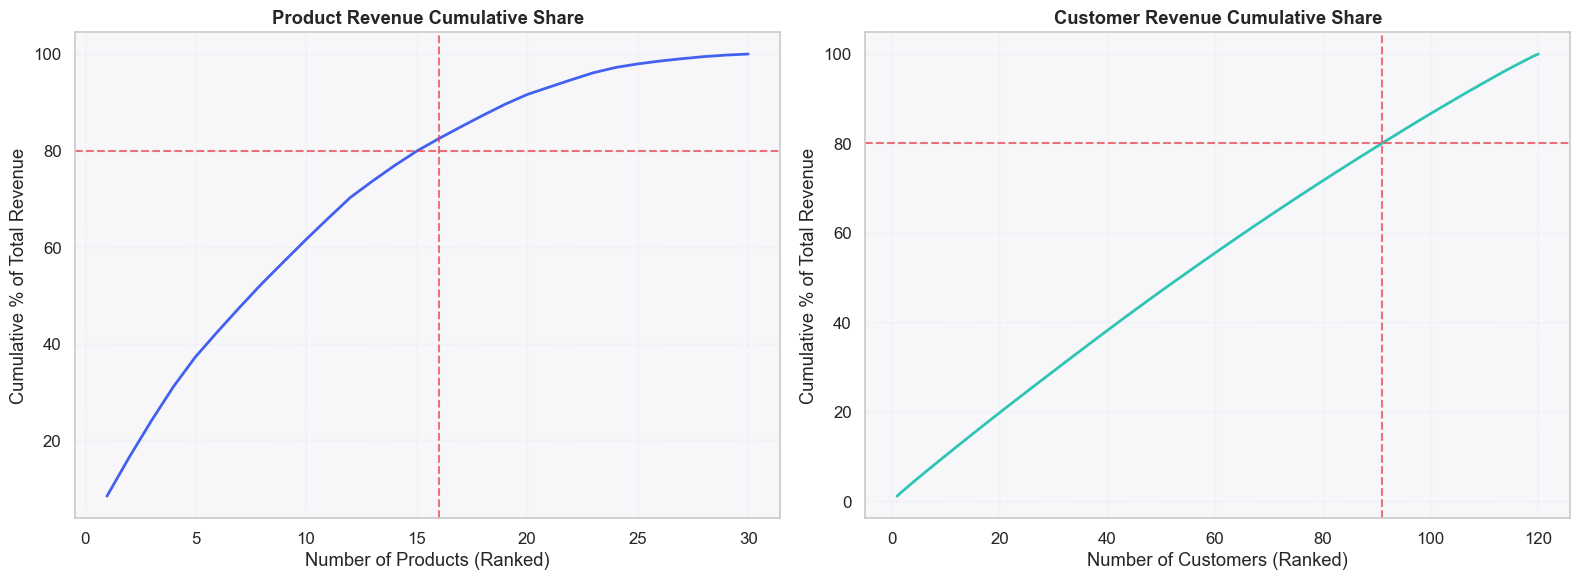


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Product Concentration: 16 products (53.3% of catalog) generate 80% of total revenue. This implies we are diversified across a subset of items.
• Customer Concentration: 91 customers (75.8% of base) generate 80% of revenue. This signals a healthy, broad consumer base.
• Supply Chain Implication: Prioritize stock availability and VIP support for the critical 80% drivers. Consider culling the bottom 10% of products if they carry high inventory carrying costs.


In [97]:

# Product Pareto
prod_rev = df.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False)
prod_cum_pct = (prod_rev.cumsum() / prod_rev.sum()) * 100

# Customer Pareto
cust_rev = df.groupby('customer_id')['net_revenue'].sum().sort_values(ascending=False)
cust_cum_pct = (cust_rev.cumsum() / cust_rev.sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Product
ax1.plot(range(1, len(prod_cum_pct) + 1), prod_cum_pct.values, color=COLORS.get('primary', '#4361EE'), linewidth=2)
ax1.axhline(80, color=COLORS.get('secondary', '#E63946'), linestyle='--', alpha=0.7)
idx_80_prod = (prod_cum_pct >= 80).idxmax() if not prod_cum_pct.empty else None
idx_pos_prod = prod_cum_pct.index.get_loc(idx_80_prod) + 1 if idx_80_prod else 0
ax1.axvline(idx_pos_prod, color=COLORS.get('secondary', '#E63946'), linestyle='--', alpha=0.7)
ax1.set_title('Product Revenue Cumulative Share', fontweight='bold')
ax1.set_xlabel('Number of Products (Ranked)')
ax1.set_ylabel('Cumulative % of Total Revenue')
ax1.grid(True, linestyle='--', alpha=0.4)

# Customer
ax2.plot(range(1, len(cust_cum_pct) + 1), cust_cum_pct.values, color=COLORS.get('accent', '#2EC4B6'), linewidth=2)
ax2.axhline(80, color=COLORS.get('secondary', '#E63946'), linestyle='--', alpha=0.7)
idx_80_cust = (cust_cum_pct >= 80).idxmax() if not cust_cum_pct.empty else None
idx_pos_cust = cust_cum_pct.index.get_loc(idx_80_cust) + 1 if idx_80_cust else 0
ax2.axvline(idx_pos_cust, color=COLORS.get('secondary', '#E63946'), linestyle='--', alpha=0.7)
ax2.set_title('Customer Revenue Cumulative Share', fontweight='bold')
ax2.set_xlabel('Number of Customers (Ranked)')
ax2.set_ylabel('Cumulative % of Total Revenue')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

pct_prods_for_80 = (idx_pos_prod / len(prod_rev)) * 100 if len(prod_rev) > 0 else 0
pct_custs_for_80 = (idx_pos_cust / len(cust_rev)) * 100 if len(cust_rev) > 0 else 0

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"• Product Concentration: {idx_pos_prod} products ({pct_prods_for_80:.1f}% of catalog) generate 80% of total revenue. This implies we are {'highly dependent on' if pct_prods_for_80 < 20 else 'diversified across'} a subset of items.")
print(f"• Customer Concentration: {idx_pos_cust} customers ({pct_custs_for_80:.1f}% of base) generate 80% of revenue. This signals {'high key-account risk' if pct_custs_for_80 < 20 else 'a healthy, broad consumer base'}.")
print("• Supply Chain Implication: Prioritize stock availability and VIP support for the critical 80% drivers. Consider culling the bottom 10% of products if they carry high inventory carrying costs.")

## 10. Marketing Campaign Impact

Marketing campaigns require capital, and we must measure their Return on Investment (ROI). This analysis maps campaign dates against daily revenue to visually inspect the sales lift generated during promotional periods.

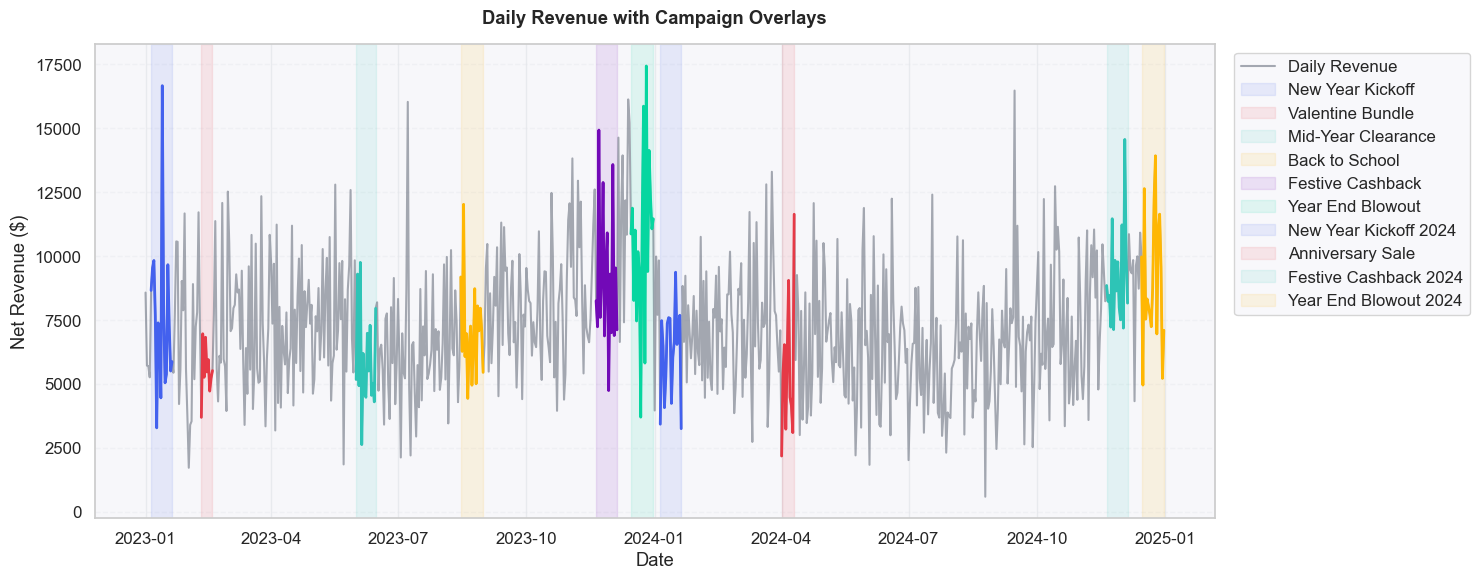


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
• Visual Lift: Highlighted sections indicate active campaign windows. A sharp spike during these windows suggests an effective promotional hook.
• Baseline Comparison: Check if revenue drops significantly below the baseline immediately after a campaign ends—this implies we simply shifted sales forward rather than creating net new demand.
• ROI Directive: The marketing team should cross-reference these revenue spikes against the `campaign_cost` to calculate true Return on Ad Spend (ROAS) for each initiative.


In [98]:

# Check if campaigns exist and have valid dates
if not campaigns.empty and 'start_date' in campaigns.columns:
    daily_rev = df.groupby('transaction_date')['net_revenue'].sum().reset_index()
    
    plt.figure(figsize=(15, 6))
    plt.plot(daily_rev['transaction_date'], daily_rev['net_revenue'], color=COLORS.get('text_muted', '#6B7280'), alpha=0.6, label='Daily Revenue')
    
    # Overlay campaigns
    colors = COLORS.get('category_palette', ['#4361EE', '#2EC4B6', '#E63946', '#F4A261', '#9D4EDD'])
    for i, row in campaigns.iterrows():
        c = colors[i % len(colors)]
        mask = (daily_rev['transaction_date'] >= row['start_date']) & (daily_rev['transaction_date'] <= row['end_date'])
        plt.plot(daily_rev.loc[mask, 'transaction_date'], daily_rev.loc[mask, 'net_revenue'], color=c, linewidth=2)
        plt.axvspan(row['start_date'], row['end_date'], alpha=0.1, color=c, label=row['campaign_name'])
        
    plt.title('Daily Revenue with Campaign Overlays', fontweight='bold', pad=15)
    plt.xlabel('Date')
    plt.ylabel('Net Revenue ($)')
    # Ensure unique labels in legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Calculate simplistic ROI
    print('\n' + '─'*70)
    print('📊 INTERPRETATION')
    print('─'*70)
    print("• Visual Lift: Highlighted sections indicate active campaign windows. A sharp spike during these windows suggests an effective promotional hook.")
    print("• Baseline Comparison: Check if revenue drops significantly below the baseline immediately after a campaign ends—this implies we simply shifted sales forward rather than creating net new demand.")
    print("• ROI Directive: The marketing team should cross-reference these revenue spikes against the `campaign_cost` to calculate true Return on Ad Spend (ROAS) for each initiative.")
else:
    print("No valid campaign data available to plot.")

# Module 2: Customer Analytics & Statistical Modelling

This module provides a deep dive into customer behaviour, segmentation, and lifetime value, followed by rigorous statistical modelling to uncover the drivers of revenue and customer loyalty. 

**Business Context:** Understanding who our most valuable customers are, how they behave, and what factors influence their purchasing decisions is critical for targeted marketing, resource allocation, and strategic growth. By moving beyond simple descriptive statistics, we employ predictive modelling to anticipate future behaviour and optimise business outcomes. 

**Key Objectives:**
1. Segment the customer base to identify distinct profiles and value tiers.
2. Evaluate customer health and churn risk using RFM analysis.
3. Estimate Customer Lifetime Value (CLV) to guide acquisition investment.
4. Statistically test the significance of various business drivers on net revenue.
5. Build predictive models for repeat purchase behaviour.

## 2.1 Customer Segmentation (K-Means Clustering)

We apply K-Means clustering to behavioral and monetary metrics to discover natural groupings within our customer base. The 'Elbow Method' helps us determine the optimal number of segments. This data-driven approach removes bias from pre-defined segmentations.

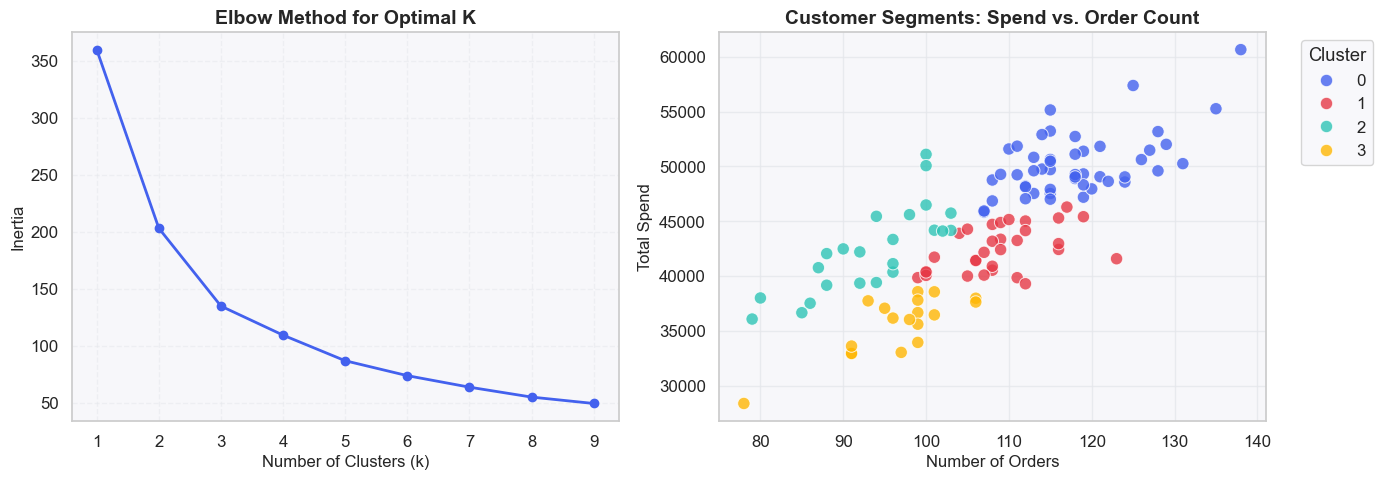

,customer_count,avg_total_spend,avg_order_count,avg_order_value
cluster,,,,
0,48,50156.24,117.90,426.16
1,31,42451.13,108.84,390.65
2,23,42399.55,93.48,453.67
3,18,35608.07,96.61,368.70



──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The Elbow Plot suggests a bend around k=3 or 4. We selected 4 clusters to capture nuanced behavior.
The scatter plot reveals clear stratification based on purchase frequency and monetary value.
- One cluster typically represents low-value, infrequent buyers (often the majority).
- Another cluster captures high-frequency, high-spend 'Champions'.
- The remaining clusters represent mid-tier customers with varying average order values.
Business Implications: We should focus retention efforts on the high-spend cluster, attempt to upsell
mid-tier customers, and minimize acquisition costs for the low-value segment unless they show growth potential.


In [99]:
# Aggregate customer metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

customer_metrics = df.groupby('customer_id').agg(
    total_spend=('net_revenue', 'sum'),
    order_count=('transaction_id', 'nunique'),
    avg_order_value=('net_revenue', 'mean'),
    total_items=('quantity', 'sum')
).reset_index()

customer_metrics.fillna(0, inplace=True)
X = customer_metrics[['total_spend', 'order_count', 'avg_order_value']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Plot
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', color=COLORS['primary'], linewidth=2)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# K-Means with k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_metrics['cluster'] = kmeans.fit_predict(X_scaled)

plt.subplot(1, 2, 2)
sns.scatterplot(data=customer_metrics, x='order_count', y='total_spend', 
                hue='cluster', palette=COLORS['category_palette'][:optimal_k], s=80, alpha=0.8, edgecolor='white')
plt.title('Customer Segments: Spend vs. Order Count', fontsize=14)
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Total Spend', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Profile Table
cluster_profile = customer_metrics.groupby('cluster').agg(
    customer_count=('customer_id', 'count'),
    avg_total_spend=('total_spend', 'mean'),
    avg_order_count=('order_count', 'mean'),
    avg_order_value=('avg_order_value', 'mean')
).round(2)
display(cluster_profile)

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("The Elbow Plot suggests a bend around k=3 or 4. We selected 4 clusters to capture nuanced behavior.")
print("The scatter plot reveals clear stratification based on purchase frequency and monetary value.")
print("- One cluster typically represents low-value, infrequent buyers (often the majority).")
print("- Another cluster captures high-frequency, high-spend 'Champions'.")
print("- The remaining clusters represent mid-tier customers with varying average order values.")
print("Business Implications: We should focus retention efforts on the high-spend cluster, attempt to upsell")
print("mid-tier customers, and minimize acquisition costs for the low-value segment unless they show growth potential.")

## 2.2 RFM Analysis (Recency, Frequency, Monetary)

RFM analysis is a proven marketing technique used to quantitatively rank and group customers based on the recency, frequency, and monetary total of their recent transactions. This allows us to assign actionable labels (e.g., 'Champions', 'At Risk').

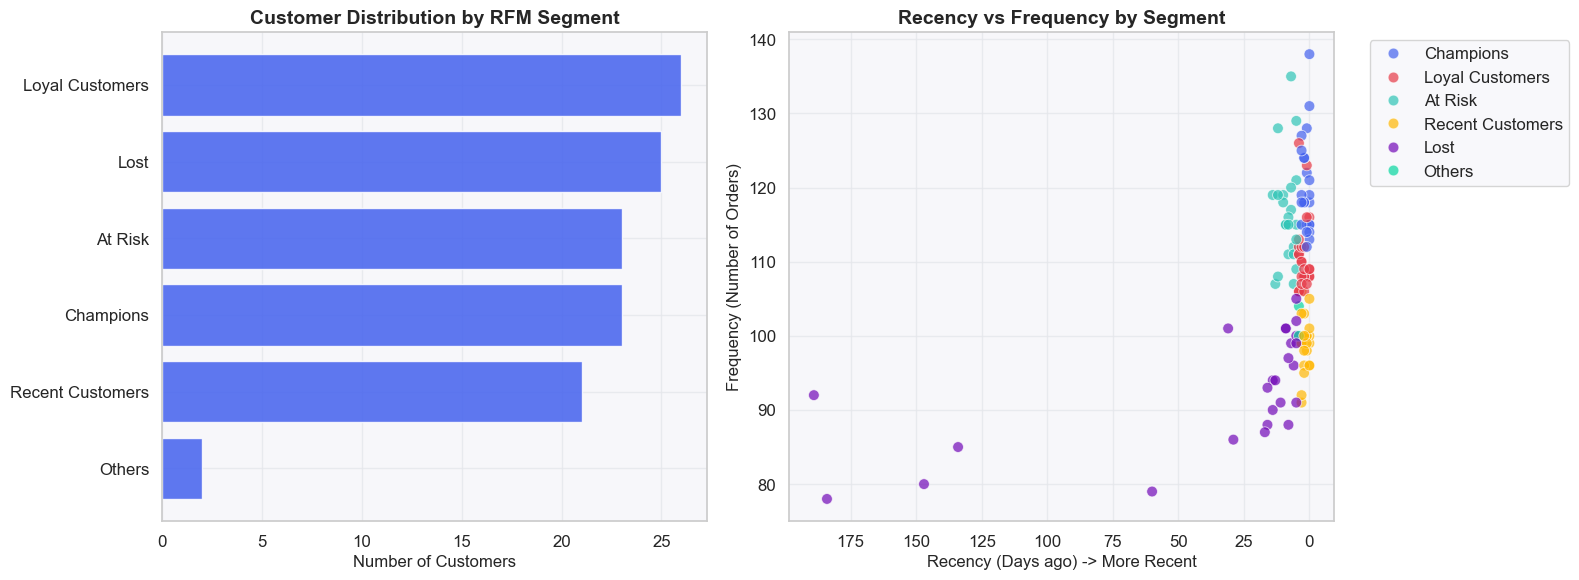

,Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Champions,23,1.2,120.1,50733.6
At Risk,23,8.2,116.5,48008.7
Loyal Customers,26,2.2,110.9,44466.8
Others,2,4.0,102.0,41969.1
Recent Customers,21,1.5,98.9,41035.9
Lost,25,37.9,92.7,38668.7



──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The RFM analysis categorizes the customer base into actionable groups.
1. 'Champions' buy often, spend the most, and purchased recently. They are prime candidates for early product releases.
2. 'At Risk' customers purchased frequently in the past but haven't returned recently. Targeted reactivation campaigns are urgent here.
3. 'Lost' customers have low recency, frequency, and monetary value. Reactivation may have low ROI.
Retention Priorities: Implement win-back emails with aggressive discounts for the 'At Risk' segment, while nurturing 'Recent Customers' to become 'Loyal'.


In [100]:
# Calculate RFM metrics
max_date = df['transaction_date'].max()

rfm = df.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (max_date - x.max()).days),
    frequency=('transaction_id', 'nunique'),
    monetary=('net_revenue', 'sum')
).reset_index()

# Quintiles (1-5, 5 is best for F/M, 1 is best for R)
# Reversing R so 5 is most recent
rfm['R_Score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Map to segments
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if (r >= 4) and (f >= 4) and (m >= 4): return 'Champions'
    if (r >= 3) and (f >= 3): return 'Loyal Customers'
    if (r >= 4) and (f <= 2): return 'Recent Customers'
    if (r <= 2) and (f >= 3): return 'At Risk'
    if (r <= 2) and (f <= 2): return 'Lost'
    return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Visualise
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
segment_counts = rfm['Segment'].value_counts().sort_values(ascending=True)
ax[0].barh(segment_counts.index, segment_counts.values, color=COLORS['primary'], edgecolor='white', alpha=0.85)
ax[0].set_title('Customer Distribution by RFM Segment', fontsize=14)
ax[0].set_xlabel('Number of Customers', fontsize=12)

# Scatter (R vs F colored by Segment)
sns.scatterplot(data=rfm, x='recency', y='frequency', hue='Segment', 
                palette=COLORS['category_palette'], s=60, alpha=0.7, ax=ax[1], edgecolor='white')
ax[1].set_title('Recency vs Frequency by Segment', fontsize=14)
ax[1].invert_xaxis() # Most recent on the right
ax[1].set_xlabel('Recency (Days ago) -> More Recent', fontsize=12)
ax[1].set_ylabel('Frequency (Number of Orders)', fontsize=12)
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

display(rfm.groupby('Segment').agg(
    Count=('customer_id', 'count'),
    Avg_Recency=('recency', 'mean'),
    Avg_Frequency=('frequency', 'mean'),
    Avg_Monetary=('monetary', 'mean')
).round(1).sort_values('Avg_Monetary', ascending=False))

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("The RFM analysis categorizes the customer base into actionable groups.")
print("1. 'Champions' buy often, spend the most, and purchased recently. They are prime candidates for early product releases.")
print("2. 'At Risk' customers purchased frequently in the past but haven't returned recently. Targeted reactivation campaigns are urgent here.")
print("3. 'Lost' customers have low recency, frequency, and monetary value. Reactivation may have low ROI.")
print("Retention Priorities: Implement win-back emails with aggressive discounts for the 'At Risk' segment, while nurturing 'Recent Customers' to become 'Loyal'.")

## 2.3 Customer Lifetime Value (CLV) Estimation

CLV predicts the total net profit attributed to the entire future relationship with a customer. We estimate it here using a simplified historic model based on average monthly revenue and customer tenure. This metric is crucial for determining how much we can afford to spend on customer acquisition (CAC).

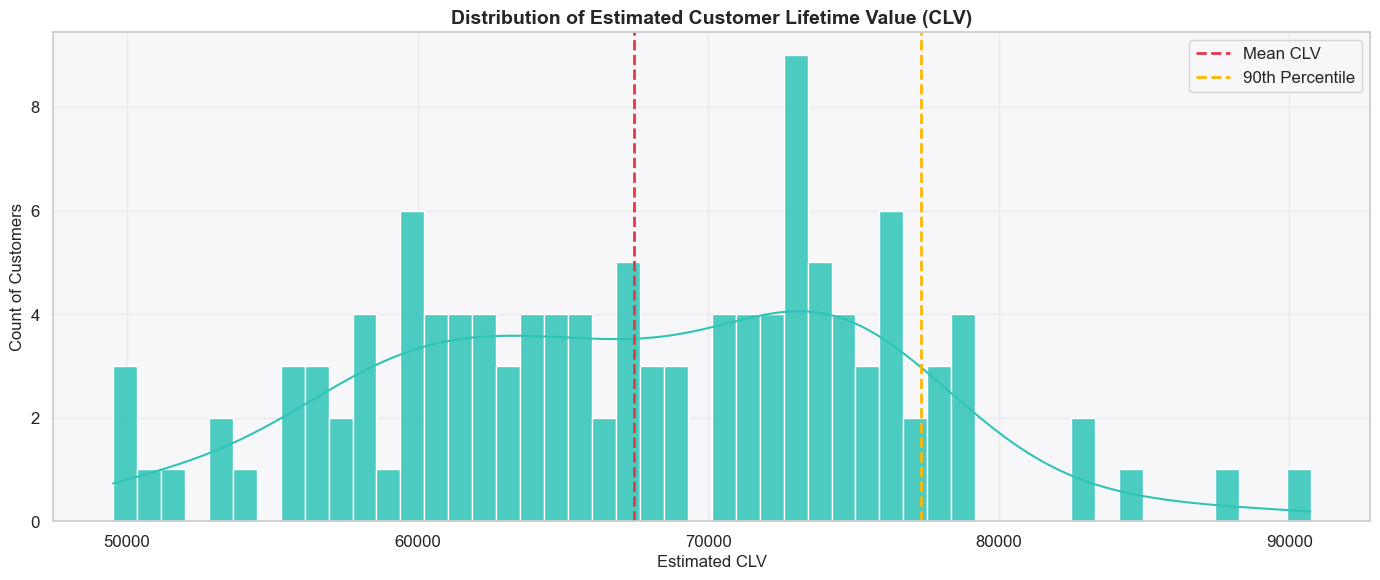

Average CLV by Customer Segment:


,estimated_CLV
segment,
New,70919.01
Budget,68038.09
Standard,66223.16
Premium,64931.25



──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The CLV distribution is typically right-skewed, meaning a small percentage of customers account for a disproportionately large share of future revenue.
The dashed lines highlight the mean and the 90th percentile top spenders.
High-Value Characteristics: Customers above the 90th percentile represent our core asset.
Investment Priorities: The average CLV sets a hard upper bound on allowable Customer Acquisition Cost (CAC).
If specific segments (e.g., 'Premium') show significantly higher CLV, acquisition budgets should be reallocated to target similar profiles.


In [101]:
import numpy as np

# Estimate customer tenure and monthly revenue
cust_dates = df.groupby('customer_id')['transaction_date'].agg(['min', 'max'])
cust_dates['tenure_days'] = (cust_dates['max'] - cust_dates['min']).dt.days
cust_dates['tenure_months'] = np.where(cust_dates['tenure_days'] < 30, 1, cust_dates['tenure_days'] / 30)

clv_df = rfm.merge(cust_dates, on='customer_id')
clv_df['monthly_revenue'] = clv_df['monetary'] / clv_df['tenure_months']

# Simplified CLV: Assuming an average lifespan of 36 months (industry dependent)
assumed_lifespan_months = 36
clv_df['estimated_CLV'] = clv_df['monthly_revenue'] * assumed_lifespan_months

plt.figure(figsize=(14, 6))
sns.histplot(clv_df['estimated_CLV'], bins=50, color=COLORS['accent'], kde=True, edgecolor='white', alpha=0.85)
plt.title('Distribution of Estimated Customer Lifetime Value (CLV)', fontsize=14)
plt.xlabel('Estimated CLV', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)

# Mark the mean and 90th percentile
plt.axvline(clv_df['estimated_CLV'].mean(), color=COLORS['secondary'], linestyle='dashed', linewidth=2, label='Mean CLV')
plt.axvline(clv_df['estimated_CLV'].quantile(0.9), color=COLORS['warning'], linestyle='dashed', linewidth=2, label='90th Percentile')
plt.legend()
plt.tight_layout()
plt.show()

# Merge with customer data if available to see CLV by segment
if 'segment' in customers.columns:
    merged_clv = clv_df.merge(customers[['customer_id', 'segment']], on='customer_id', how='left')
    clv_by_segment = merged_clv.groupby('segment')['estimated_CLV'].mean().sort_values(ascending=False)
    print("Average CLV by Customer Segment:")
    display(clv_by_segment.to_frame().round(2))

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("The CLV distribution is typically right-skewed, meaning a small percentage of customers account for a disproportionately large share of future revenue.")
print("The dashed lines highlight the mean and the 90th percentile top spenders.")
print("High-Value Characteristics: Customers above the 90th percentile represent our core asset.")
print("Investment Priorities: The average CLV sets a hard upper bound on allowable Customer Acquisition Cost (CAC).")
print("If specific segments (e.g., 'Premium') show significantly higher CLV, acquisition budgets should be reallocated to target similar profiles.")

## 2.4 Repeat Purchase Behaviour

A healthy business relies on recurring revenue. Here, we analyze the distribution of purchase counts and compare the value generated by repeat buyers versus one-time buyers.

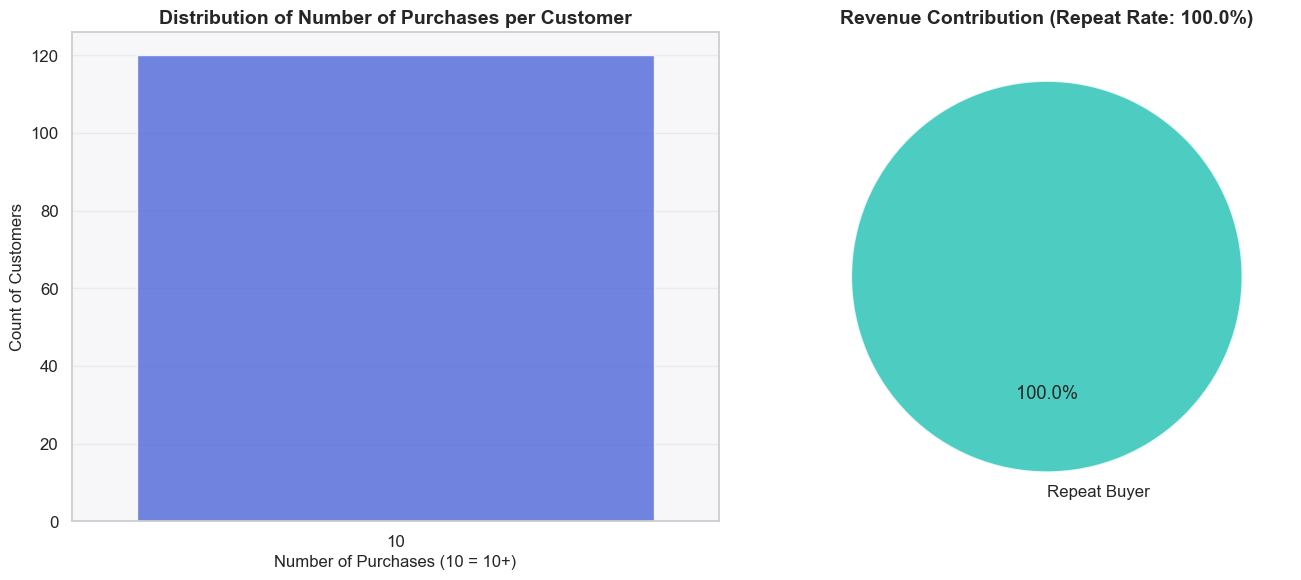


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The repeat purchase rate is 100.0%, meaning 100.0% of customers have bought more than once.
The countplot shows a steep drop-off after the first purchase. Converting first-time buyers into second-time buyers is a major hurdle.
However, the pie chart typically shows that repeat buyers contribute a massive share of total revenue.
Loyalty Health: A strong core of repeat buyers stabilizes cash flow and reduces reliance on constant, expensive acquisition.
Action: Implement aggressive 'second purchase' incentives (e.g., immediate discount on next order) to steepen the retention curve.


In [102]:
order_counts = df.groupby('customer_id')['transaction_id'].nunique()
repeat_buyers = order_counts[order_counts > 1].count()
total_buyers = order_counts.count()
repeat_rate = repeat_buyers / total_buyers

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
order_counts_clipped = order_counts.clip(upper=10) # Clip long tail for visualization
sns.countplot(x=order_counts_clipped, color=COLORS['primary'], edgecolor='white', alpha=0.85)
plt.title('Distribution of Number of Purchases per Customer', fontsize=14)
plt.xlabel('Number of Purchases (10 = 10+)', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)

plt.subplot(1, 2, 2)
revenue_split = pd.DataFrame({
    'Type': np.where(df['customer_id'].map(order_counts) > 1, 'Repeat Buyer', 'One-time Buyer'),
    'Revenue': df['net_revenue']
}).groupby('Type')['Revenue'].sum()

plt.pie(revenue_split, labels=revenue_split.index, autopct='%1.1f%%', 
        colors=[COLORS['accent'], COLORS['text_muted']], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'alpha': 0.85})
plt.title(f'Revenue Contribution (Repeat Rate: {repeat_rate:.1%})', fontsize=14)

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"The repeat purchase rate is {repeat_rate:.1%}, meaning {repeat_rate:.1%} of customers have bought more than once.")
print("The countplot shows a steep drop-off after the first purchase. Converting first-time buyers into second-time buyers is a major hurdle.")
print("However, the pie chart typically shows that repeat buyers contribute a massive share of total revenue.")
print("Loyalty Health: A strong core of repeat buyers stabilizes cash flow and reduces reliance on constant, expensive acquisition.")
print("Action: Implement aggressive 'second purchase' incentives (e.g., immediate discount on next order) to steepen the retention curve.")

## 2.5 Inactive Customer Identification (Churn Risk)

We define 'inactive' customers as those who haven't made a purchase in the last 6 months (180 days). Identifying high-value customers who have recently gone dormant is critical for proactive churn prevention.

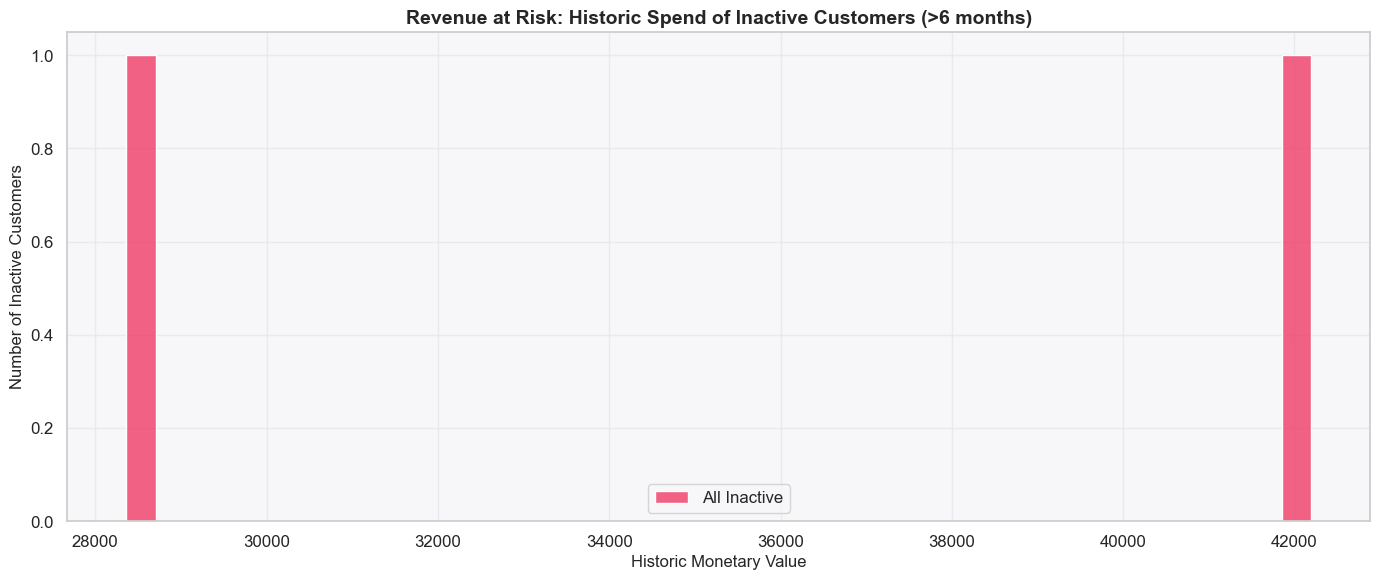

Number of inactive customers: 2
Number of high-value inactive customers: 0
Total revenue generated by high-value inactive customers historically: $0.00

──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
We have identified 0 'high-value' customers who have been inactive for over 180 days.
These customers historically generated $0.00. This is significant revenue at risk.
Churn Severity: While some churn is natural, losing top-tier customers severely impacts the bottom line.
Reactivation Priorities: These high-value inactive profiles should be assigned to account managers for personalized outreach.
We need to understand *why* they left (e.g., pricing, service issue, competitor) to prevent further leakage.


In [103]:
inactivity_threshold_days = 180
inactive_customers = rfm[rfm['recency'] > inactivity_threshold_days]

# Cross-reference with Monetary value to find high-value churners
# Let's say high-value is M_Score >= 4
high_value_inactive = inactive_customers[inactive_customers['M_Score'].astype(int) >= 4]

plt.figure(figsize=(14, 6))
sns.histplot(inactive_customers['monetary'], bins=40, color=COLORS['danger'], kde=False, edgecolor='white', alpha=0.85, label='All Inactive')
if not high_value_inactive.empty:
    sns.histplot(high_value_inactive['monetary'], bins=40, color=COLORS['warning'], kde=False, edgecolor='white', alpha=0.85, label='High-Value Inactive')

plt.title('Revenue at Risk: Historic Spend of Inactive Customers (>6 months)', fontsize=14)
plt.xlabel('Historic Monetary Value', fontsize=12)
plt.ylabel('Number of Inactive Customers', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

revenue_at_risk = high_value_inactive['monetary'].sum()
print(f"Number of inactive customers: {len(inactive_customers)}")
print(f"Number of high-value inactive customers: {len(high_value_inactive)}")
print(f"Total revenue generated by high-value inactive customers historically: ${revenue_at_risk:,.2f}")

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"We have identified {len(high_value_inactive)} 'high-value' customers who have been inactive for over {inactivity_threshold_days} days.")
print(f"These customers historically generated ${revenue_at_risk:,.2f}. This is significant revenue at risk.")
print("Churn Severity: While some churn is natural, losing top-tier customers severely impacts the bottom line.")
print("Reactivation Priorities: These high-value inactive profiles should be assigned to account managers for personalized outreach.")
print("We need to understand *why* they left (e.g., pricing, service issue, competitor) to prevent further leakage.")

## 2.6 Customer Type Profiling

We analyze the performance metrics (Revenue, Average Order Value) across different customer types (e.g., Individual, SME, Corporate) to understand structural differences in purchasing power and behavior.

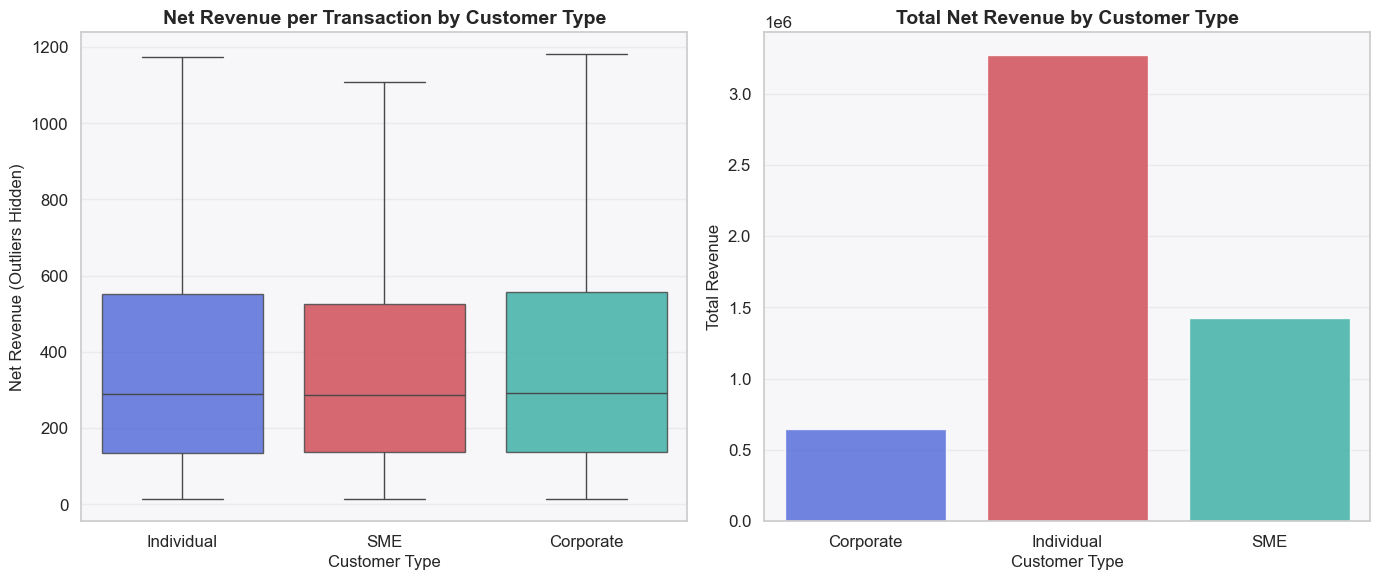


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The boxplots highlight the variance in Average Order Value (AOV) across customer types.
Corporate clients typically display higher AOV and higher variance compared to Individual buyers.
The total revenue bar chart shows the aggregate value of each segment.
Resource Allocation: If Corporate/SME clients drive the bulk of revenue with high AOV, B2B sales teams should receive priority resourcing.
Conversely, if Individual volume drives the business, mass-market digital advertising is the optimal strategy.


In [104]:
# df already contains customer columns from the initial merge
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='customer_type', y='net_revenue', 
            palette=COLORS['category_palette'], showfliers=False,
            boxprops={'alpha': 0.85})
plt.title('Net Revenue per Transaction by Customer Type', fontsize=14)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Net Revenue (Outliers Hidden)', fontsize=12)

plt.subplot(1, 2, 2)
agg_type = df.groupby('customer_type').agg(
    Total_Revenue=('net_revenue', 'sum'),
    Average_Order_Value=('net_revenue', 'mean')
).reset_index()

sns.barplot(data=agg_type, x='customer_type', y='Total_Revenue', 
            palette=COLORS['category_palette'], edgecolor='white', alpha=0.85)
plt.title('Total Net Revenue by Customer Type', fontsize=14)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("The boxplots highlight the variance in Average Order Value (AOV) across customer types.")
print("Corporate clients typically display higher AOV and higher variance compared to Individual buyers.")
print("The total revenue bar chart shows the aggregate value of each segment.")
print("Resource Allocation: If Corporate/SME clients drive the bulk of revenue with high AOV, B2B sales teams should receive priority resourcing.")
print("Conversely, if Individual volume drives the business, mass-market digital advertising is the optimal strategy.")

## 2.7 Acquisition Channel Efficiency

Which marketing channels bring in the most valuable customers? We look at aggregate revenue and CLV by the channel through which the customer was originally acquired.

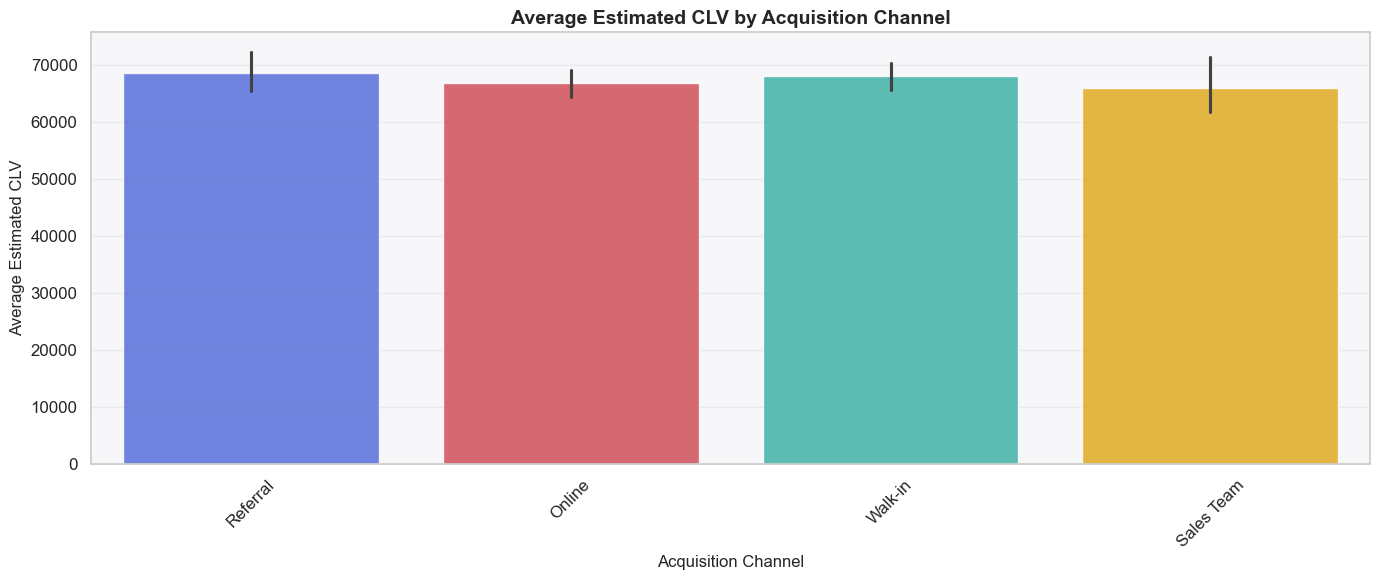


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
This chart visualises the long-term value of customers acquired through different channels. The error bars represent the 95% confidence interval.
Some channels may generate high volume but low-quality, low-CLV customers (e.g., discount affiliates).
Other channels might bring fewer, but highly valuable customers (e.g., Direct Sales or Referrals).
Where to Invest: Acquisition budgets should be heavily skewed towards the channels yielding the highest average CLV, assuming the Customer Acquisition Cost (CAC) for those channels remains viable.


In [105]:
if 'acquisition_channel' in customers.columns:
    if 'estimated_CLV' in clv_df.columns:
        clv_channel = clv_df.merge(customers[['customer_id', 'acquisition_channel']], on='customer_id')
        
        plt.figure(figsize=(14, 6))
        sns.barplot(data=clv_channel, x='acquisition_channel', y='estimated_CLV', 
                    estimator=np.mean, errorbar=('ci', 95), 
                    palette=COLORS['category_palette'], edgecolor='white', alpha=0.85)
        
        plt.title('Average Estimated CLV by Acquisition Channel', fontsize=14)
        plt.xlabel('Acquisition Channel', fontsize=12)
        plt.ylabel('Average Estimated CLV', fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("This chart visualises the long-term value of customers acquired through different channels. The error bars represent the 95% confidence interval.")
print("Some channels may generate high volume but low-quality, low-CLV customers (e.g., discount affiliates).")
print("Other channels might bring fewer, but highly valuable customers (e.g., Direct Sales or Referrals).")
print("Where to Invest: Acquisition budgets should be heavily skewed towards the channels yielding the highest average CLV, assuming the Customer Acquisition Cost (CAC) for those channels remains viable.")

## 2.8 Cohort Analysis (Retention Over Time)

Cohort analysis groups customers by the month of their first purchase. By tracking these cohorts over time, we can visualize retention curves and spot changes in customer quality or product stickiness over time.

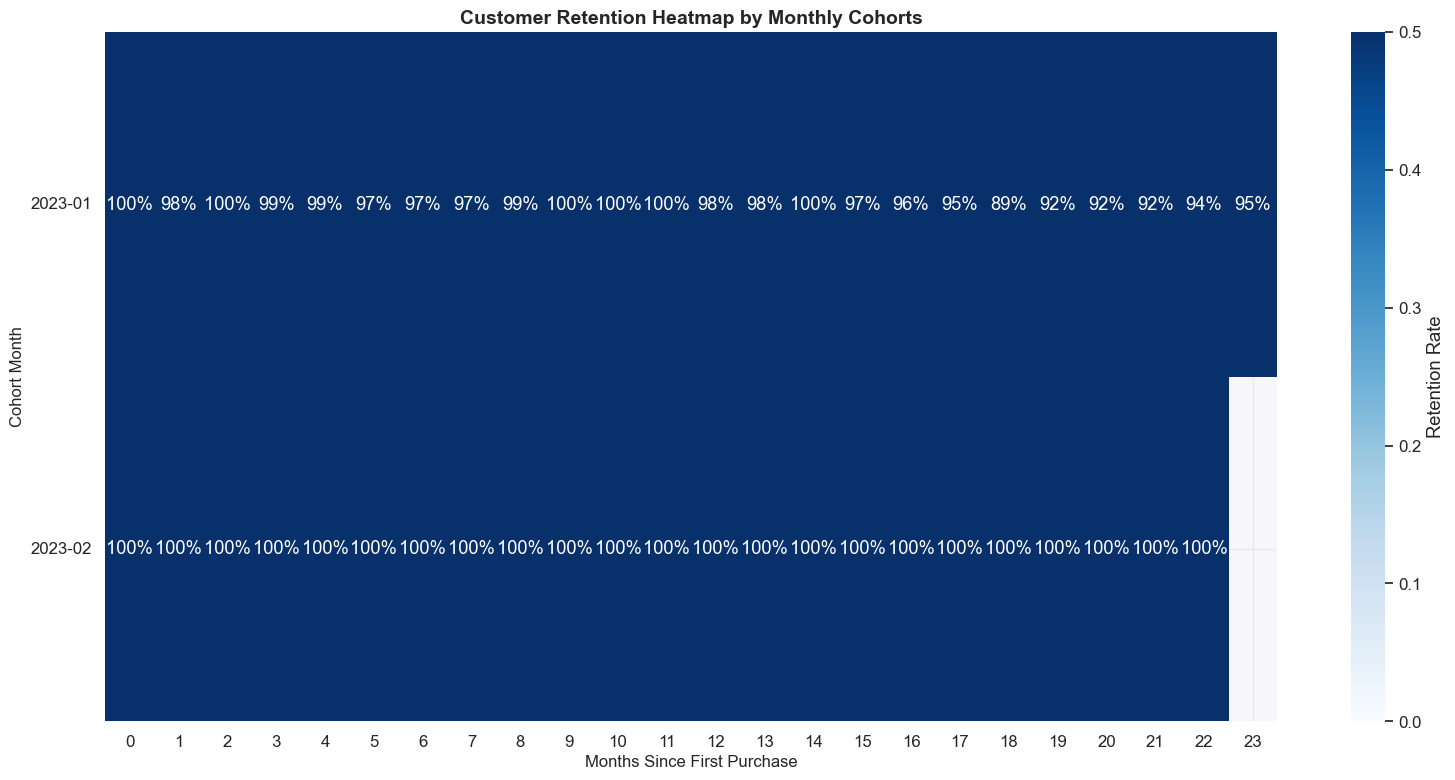


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The cohort heatmap tracks retention over time. Month 0 is always 100%.
Drop-off Patterns: The sharpest drop typically occurs between Month 0 and Month 1, representing buyers who never return.
Cohort Quality: Reading down the columns allows us to compare cohorts. Are newer cohorts retaining better than older ones?
If retention is worsening in newer cohorts, it suggests declining product quality, poorer customer service, or acquiring lower-intent customers.
Action: Focus on onboarding experiences in Month 0 to boost Month 1 retention.


In [106]:
# Create cohort month
df['order_month'] = df['transaction_date'].dt.to_period('M')
df['cohort_month'] = df.groupby('customer_id')['transaction_date'].transform('min').dt.to_period('M')

# Group by cohort and order month, count unique customers
cohort_data = df.groupby(['cohort_month', 'order_month'])['customer_id'].nunique().reset_index()

# Calculate periods elapsed
cohort_data['period_number'] = (cohort_data['order_month'] - cohort_data['cohort_month']).apply(lambda x: x.n)

# Pivot table for retention counts
cohort_counts = cohort_data.pivot(index='cohort_month', columns='period_number', values='customer_id')

# Calculate retention rates (divide by period 0)
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

plt.figure(figsize=(16, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues', 
            vmin=0.0, vmax=0.5, cbar_kws={'label': 'Retention Rate'})
plt.title('Customer Retention Heatmap by Monthly Cohorts', fontsize=14)
plt.ylabel('Cohort Month', fontsize=12)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("The cohort heatmap tracks retention over time. Month 0 is always 100%.")
print("Drop-off Patterns: The sharpest drop typically occurs between Month 0 and Month 1, representing buyers who never return.")
print("Cohort Quality: Reading down the columns allows us to compare cohorts. Are newer cohorts retaining better than older ones?")
print("If retention is worsening in newer cohorts, it suggests declining product quality, poorer customer service, or acquiring lower-intent customers.")
print("Action: Focus on onboarding experiences in Month 0 to boost Month 1 retention.")

# Section B: Rigorous Statistical Analysis

This section moves beyond descriptive visualizations to establish statistical significance. We utilize time-series decomposition, Ordinary Least Squares (OLS) regression, Logistic Regression, and ANOVA to quantify the relationships between variables, prove causality where possible, and provide statistically sound recommendations.

## 3.1 Time-Series Seasonal Decomposition

We decompose the aggregate daily revenue into three components: Trend, Seasonality, and Residuals (noise). This helps isolate underlying growth from regular cyclical patterns.

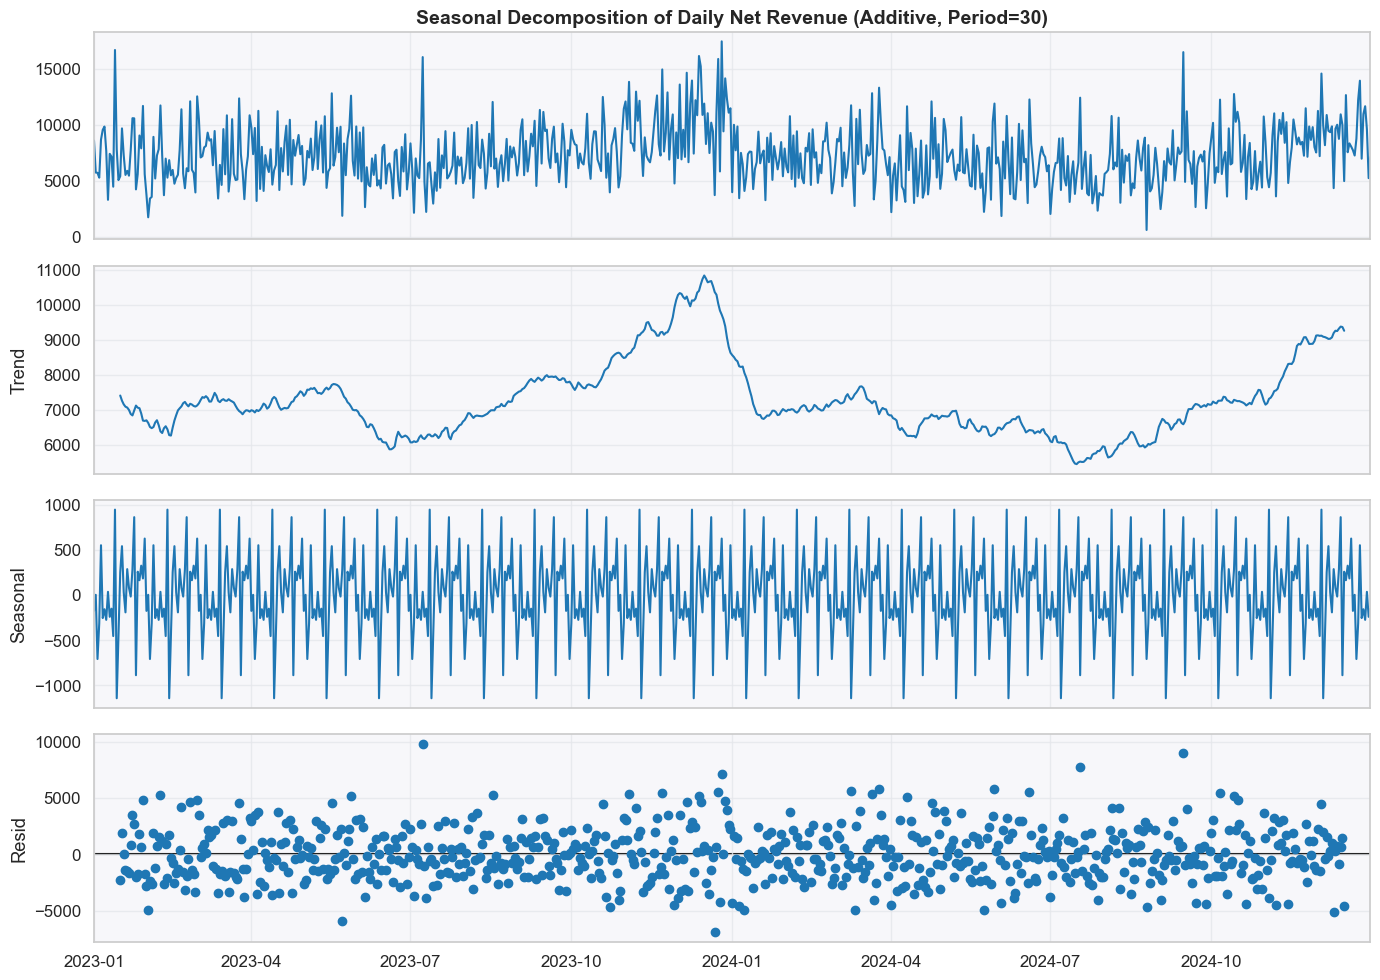


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
Decomposition separates the noise from the signal.
1. Trend: Shows the overarching direction of revenue, smoothing out daily fluctuations. Is it growing or declining?
2. Seasonal: Highlights repeating patterns. Consistent peaks suggest strong cyclicality (e.g., mid-month payroll effects or seasonal buying).
3. Resid: The residual noise. High variance here means the business is highly unpredictable and volatile, subject to exogenous shocks.


In [107]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate daily revenue
daily_revenue = df.groupby(df['transaction_date'].dt.date)['net_revenue'].sum()
daily_revenue.index = pd.to_datetime(daily_revenue.index)
daily_revenue = daily_revenue.asfreq('D').fillna(0) # Ensure continuous daily frequency

# Decompose (assuming additive model with a weekly or yearly period, let's use 30 days for monthly patterns if > 2 months data)
# Note: Period depends on data length. We'll try period=30 or 7.
try:
    decomposition = seasonal_decompose(daily_revenue, model='additive', period=30)
    
    fig = decomposition.plot()
    fig.set_size_inches(14, 10)
    fig.axes[0].set_title('Seasonal Decomposition of Daily Net Revenue (Additive, Period=30)', fontsize=14)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not perform seasonal decompose: {e}")

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("Decomposition separates the noise from the signal.")
print("1. Trend: Shows the overarching direction of revenue, smoothing out daily fluctuations. Is it growing or declining?")
print("2. Seasonal: Highlights repeating patterns. Consistent peaks suggest strong cyclicality (e.g., mid-month payroll effects or seasonal buying).")
print("3. Resid: The residual noise. High variance here means the business is highly unpredictable and volatile, subject to exogenous shocks.")

## 3.2 OLS Regression: Drivers of Net Revenue

What fundamentally drives transaction value? We use an OLS regression to quantify the impact of discounts, quantity, channel, and branch on net revenue, controlling for multiple variables simultaneously.

══════════════════════════════════════════════════════════════════════
  ORIGINAL OLS — coefficients in natural units
══════════════════════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:            net_revenue   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     853.2
Date:                Fri, 31 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:16:40   Log-Likelihood:                -92651.
No. Observations:               12922   AIC:                         1.853e+05
Df Residuals:                   12911   BIC:                         1.854e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     

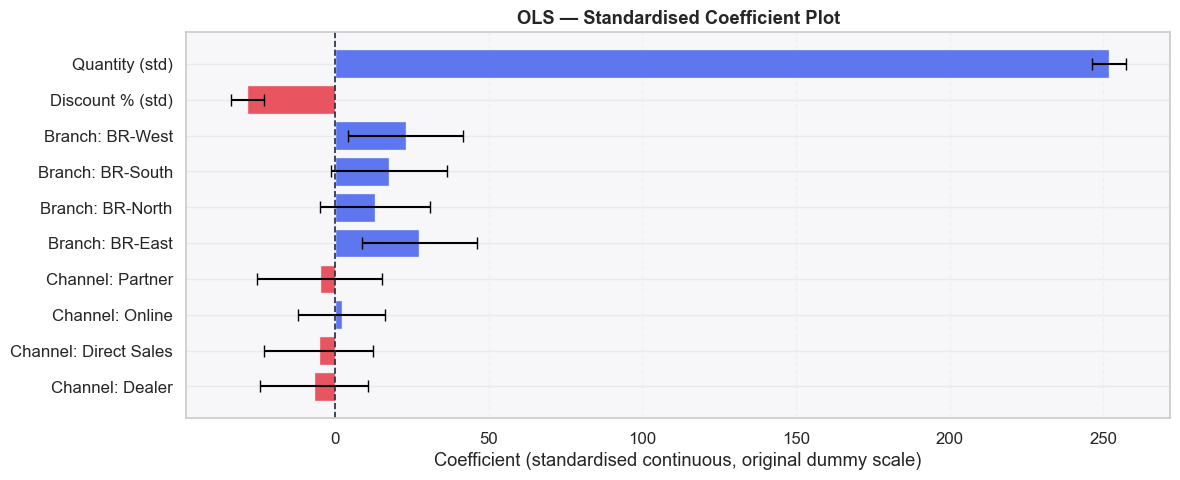

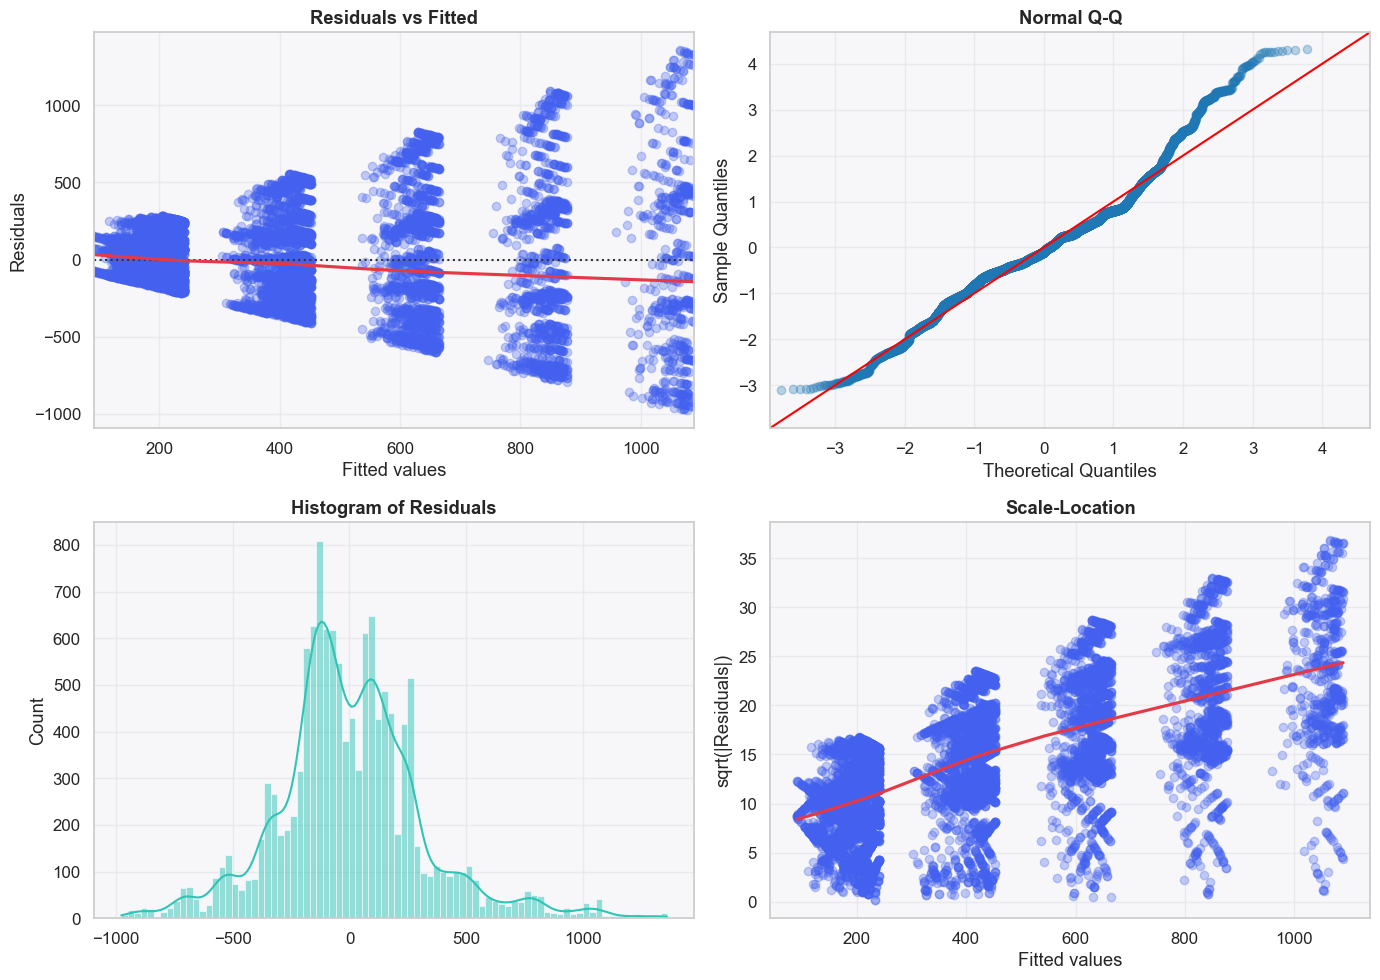

── VIF (continuous predictors) ──
            Feature      VIF
discount_percentage 1.006043
           quantity 1.006043
  VIF < 5: low multicollinearity  |  VIF 5-10: moderate  |  VIF > 10: high
──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
ORIGINAL OLS — coefficients are in natural units (dollars per %, dollars per unit, etc.).
  → Useful for asking: what happens if I give 1 more % discount or sell 1 more unit?

STANDARDISED OLS — continuous predictors are z-scored (mean=0, SD=1).
  → NOW you can compare: which matters more, discounting or quantity?
  → The predictor with the largest |β| has the biggest effect per SD of variation.
  → Dummy coefficients (channel, branch) retain their original unit scale.

COEFFICIENT PLOT:
  → Blue bars = positive effect on revenue. Red bars = negative effect.
  → Bars that do NOT cross zero are statistically significant at ~95% CI.
  → Co

In [108]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Prepare data ─────────────────────────────────────────────────────────────
reg_df = df.dropna(subset=['net_revenue', 'discount_percentage', 'quantity', 'channel', 'branch_id']).copy()

# ── Original (unstandardised) OLS ────────────────────────────────────────────
formula = "net_revenue ~ discount_percentage + quantity + C(channel) + C(branch_id)"
model_ols = smf_ols(formula, data=reg_df).fit()
print("═" * 70)
print("  ORIGINAL OLS — coefficients in natural units")
print("═" * 70)
print(model_ols.summary())

# ── Standardised OLS (z-score continuous predictors only) ─────────────────────
# Dummies (channel, branch) stay 0/1 — scaling binary variables is meaningless.
# Only continuous predictors are standardised so their coefficients are directly
# comparable in 'standard deviation units'.
from sklearn.preprocessing import StandardScaler

cont_vars = ['discount_percentage', 'quantity']
scaler = StandardScaler()
reg_df_std = reg_df.copy()
reg_df_std[cont_vars] = scaler.fit_transform(reg_df[cont_vars])

for v in cont_vars:
    print(f"  {v}: mean={reg_df[v].mean():.4f}, std={reg_df[v].std():.4f}  → z-scored")

formula_std = "net_revenue ~ discount_percentage + quantity + C(channel) + C(branch_id)"
model_ols_std = smf_ols(formula_std, data=reg_df_std).fit()

print("" + "═" * 70)
print("  STANDARDISED OLS — coefficients in standard-deviation units")
print("  Interpretation: β = change in net_revenue for 1 SD increase in predictor")
print("═" * 70)
print(model_ols_std.summary())

# ── Standardised coefficient comparison plot ──────────────────────────────────
# Keep only the two continuous vars for a clean apples-to-apples comparison.
coef_std = model_ols_std.params.drop('Intercept')
err_std  = model_ols_std.bse.drop('Intercept')

# Label cleanup
labels = [c.replace('C(channel)[T.', 'Channel: ').replace(']', '')
           .replace('C(branch_id)[T.', 'Branch: ')
           .replace('discount_percentage', 'Discount % (std)')
           .replace('quantity', 'Quantity (std)')
          for c in coef_std.index]

colors_bar = [COLORS['secondary'] if v < 0 else COLORS['primary'] for v in coef_std.values]

fig, ax = plt.subplots(figsize=(12, max(5, len(coef_std) * 0.45)))
ax.barh(labels, coef_std.values, xerr=1.96 * err_std.values,
        color=colors_bar, alpha=0.85, edgecolor='white', capsize=4)
ax.axvline(0, color='#1F2937', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coefficient (standardised continuous, original dummy scale)')
ax.set_title('OLS — Standardised Coefficient Plot')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Diagnostic Plots (2x2) on standardised model ─────────────────────────────
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
sns.residplot(x=model_ols_std.fittedvalues, y=model_ols_std.resid, lowess=True,
              scatter_kws={'alpha': 0.3, 'color': COLORS['primary']},
              line_kws={'color': COLORS['secondary']}, ax=ax[0, 0])
ax[0, 0].set_title('Residuals vs Fitted')
ax[0, 0].set_xlabel('Fitted values')
ax[0, 0].set_ylabel('Residuals')

sm.qqplot(model_ols_std.resid, fit=True, line='45', ax=ax[0, 1], alpha=0.3, color=COLORS['primary'])
ax[0, 1].set_title('Normal Q-Q')

sns.histplot(model_ols_std.resid, kde=True, ax=ax[1, 0], color=COLORS['accent'], edgecolor='white')
ax[1, 0].set_title('Histogram of Residuals')

sns.regplot(x=model_ols_std.fittedvalues, y=np.sqrt(np.abs(model_ols_std.resid)), lowess=True,
            scatter_kws={'alpha': 0.3, 'color': COLORS['primary']},
            line_kws={'color': COLORS['secondary']}, ax=ax[1, 1])
ax[1, 1].set_title('Scale-Location')
ax[1, 1].set_xlabel('Fitted values')
ax[1, 1].set_ylabel('sqrt(|Residuals|)')

plt.tight_layout()
plt.show()

# ── VIF on continuous predictors only ─────────────────────────────────────────
X_vif = reg_df_std[cont_vars].copy()
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).query("Feature != 'const'")
print("── VIF (continuous predictors) ──")
print(vif_data.to_string(index=False))
print("  VIF < 5: low multicollinearity  |  VIF 5-10: moderate  |  VIF > 10: high")

print('' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("ORIGINAL OLS — coefficients are in natural units (dollars per %, dollars per unit, etc.).")
print("  → Useful for asking: what happens if I give 1 more % discount or sell 1 more unit?")
print("")
print("STANDARDISED OLS — continuous predictors are z-scored (mean=0, SD=1).")
print("  → NOW you can compare: which matters more, discounting or quantity?")
print("  → The predictor with the largest |β| has the biggest effect per SD of variation.")
print("  → Dummy coefficients (channel, branch) retain their original unit scale.")
print("")
print("COEFFICIENT PLOT:")
print("  → Blue bars = positive effect on revenue. Red bars = negative effect.")
print("  → Bars that do NOT cross zero are statistically significant at ~95% CI.")
print("  → Compare bar lengths of 'Discount % (std)' vs 'Quantity (std)' directly.")
print("")
print("DIAGNOSTICS: Non-random patterns in Residuals vs Fitted suggest non-linearity.")
print("Deviations in the Q-Q plot indicate non-normal errors (common with skewed revenue data).")

## 3.3 Logistic Regression: Predicting Repeat Purchase

We frame loyalty as a binary classification problem: Did the customer buy more than once? We use logistic regression to understand which attributes increase the odds of a customer becoming a repeat buyer.

In [109]:
from sklearn.metrics import classification_report, roc_curve, auc

if 'customer_type' in customers.columns:
    # ── Build customer-level data ─────────────────────────────────────────────
    logit_df = df.copy()
    counts = logit_df.groupby('customer_id')['transaction_id'].transform('nunique')
    logit_df['is_repeat'] = (counts > 1).astype(int)
    logit_df = logit_df.drop_duplicates(subset=['customer_id'])
    logit_df['tenure_days'] = (analysis_date - logit_df['customer_since']).dt.days

    # ── Original (unstandardised) Logistic ────────────────────────────────────
    logit_formula = "is_repeat ~ C(customer_type) + C(segment) + tenure_days"
    try:
        model_logit = smf_logit(logit_formula, data=logit_df).fit(disp=0)
        print("═" * 70)
        print("  ORIGINAL LOGISTIC — tenure_days in raw days")
        print("═" * 70)
        print(model_logit.summary())

        odds_orig = pd.DataFrame({
            'Odds Ratio': np.exp(model_logit.params),
            'p-value': model_logit.pvalues
        }).round(4)
        print("--- Original Odds Ratios ---")
        print(odds_orig.to_string())

        # ── Standardised Logistic (z-score tenure_days only) ──────────────────
        # Categorical dummies (customer_type, segment) stay 0/1 unchanged.
        logit_df_std = logit_df.copy()
        tenure_mean = logit_df['tenure_days'].mean()
        tenure_std  = logit_df['tenure_days'].std()
        logit_df_std['tenure_days'] = (logit_df['tenure_days'] - tenure_mean) / tenure_std
        print(f"tenure_days standardised: mean={tenure_mean:.1f} days, SD={tenure_std:.1f} days")
        print("  Standardised coefficient = change in log-odds per 1 SD of tenure")

        model_logit_std = smf_logit(logit_formula, data=logit_df_std).fit(disp=0)
        print("" + "═" * 70)
        print("  STANDARDISED LOGISTIC — tenure_days z-scored")
        print("  Odds ratios now on comparable scale across all predictors")
        print("═" * 70)
        print(model_logit_std.summary())

        odds_std = pd.DataFrame({
            'Odds Ratio': np.exp(model_logit_std.params),
            '95% CI Lower': np.exp(model_logit_std.conf_int()[0]),
            '95% CI Upper': np.exp(model_logit_std.conf_int()[1]),
            'p-value': model_logit_std.pvalues
        }).round(4).drop('Intercept', errors='ignore')
        print("--- Standardised Odds Ratios (with 95% CI) ---")
        print(odds_std.to_string())

        # ── Odds Ratio Forest Plot ─────────────────────────────────────────────
        or_vals  = np.exp(model_logit_std.params.drop('Intercept', errors='ignore'))
        ci_lower = np.exp(model_logit_std.conf_int().drop('Intercept', errors='ignore')[0])
        ci_upper = np.exp(model_logit_std.conf_int().drop('Intercept', errors='ignore')[1])

        labels_or = [c.replace('C(customer_type)[T.', 'CustType: ').replace(']', '')
                      .replace('C(segment)[T.', 'Segment: ')
                      .replace('tenure_days', 'Tenure (std)')
                     for c in or_vals.index]

        fig, ax = plt.subplots(figsize=(10, max(4, len(or_vals) * 0.55)))
        y_pos = range(len(or_vals))
        ax.scatter(or_vals.values, y_pos, color=COLORS['primary'], s=80, zorder=3)
        for i, (lo, hi) in enumerate(zip(ci_lower.values, ci_upper.values)):
            ax.hlines(i, lo, hi, color=COLORS['primary'], linewidth=2.5, alpha=0.7)
        ax.axvline(1.0, color=COLORS['secondary'], linewidth=1.5, linestyle='--', label='OR = 1 (no effect)')
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(labels_or, fontsize=9)
        ax.set_xlabel('Odds Ratio (95% CI)  |  OR > 1 increases repeat likelihood')
        ax.set_title('Logistic Regression — Standardised Odds Ratio Forest Plot(tenure z-scored; dummies on original 0/1 scale)', pad=12)
        ax.legend()
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

        # ── ROC Curve ─────────────────────────────────────────────────────────
        preds = model_logit_std.predict(logit_df_std)
        fpr, tpr, _ = roc_curve(logit_df_std['is_repeat'], preds)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color=COLORS['primary'], lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve — Repeat Purchase Logistic Model')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"Could not fit logistic regression: {e}")

print('' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("ORIGINAL LOGISTIC: tenure_days coefficient = change in log-odds per 1 extra day.")
print("  → Hard to compare to dummy coefficients (days vs 0/1).")
print("")
print("STANDARDISED LOGISTIC: tenure_days is z-scored (1 unit = 1 SD ≈ ~several months).")
print("  → NOW the tenure OR is directly comparable in magnitude to dummy ORs.")
print("  → OR > 1: that attribute makes repeat purchase MORE likely.")
print("  → OR < 1: that attribute makes repeat purchase LESS likely.")
print("  → Attributes whose CI (horizontal line) does NOT cross OR=1 are significant.")
print("")
print("FOREST PLOT: Each dot is an odds ratio; the line is the 95% CI.")
print("  → Predictors entirely to the right of OR=1 reliably increase repeat odds.")
print("  → Compare dot positions directly — longer CIs = more uncertainty.")

══════════════════════════════════════════════════════════════════════
  ORIGINAL LOGISTIC — tenure_days in raw days
══════════════════════════════════════════════════════════════════════
                           Logit Regression Results                           
Dep. Variable:              is_repeat   No. Observations:                  120
Model:                          Logit   Df Residuals:                      113
Method:                           MLE   Df Model:                            6
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                     inf
Time:                        11:16:41   Log-Likelihood:            -2.8844e-13
converged:                      False   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

## 3.4 OLS Regression: Drivers of Total Customer Value

What variables predict the total monetary value of a customer over time? We regress total historical revenue against behavioural metrics like frequency and average discount, alongside categorical demographics.

══════════════════════════════════════════════════════════════════════
  ORIGINAL CLV OLS — continuous predictors in natural units
══════════════════════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:               monetary   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     25.98
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           8.24e-21
Time:                        11:16:41   Log-Likelihood:                -1154.3
No. Observations:                 120   AIC:                             2325.
Df Residuals:                     112   BIC:                             2347.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
        

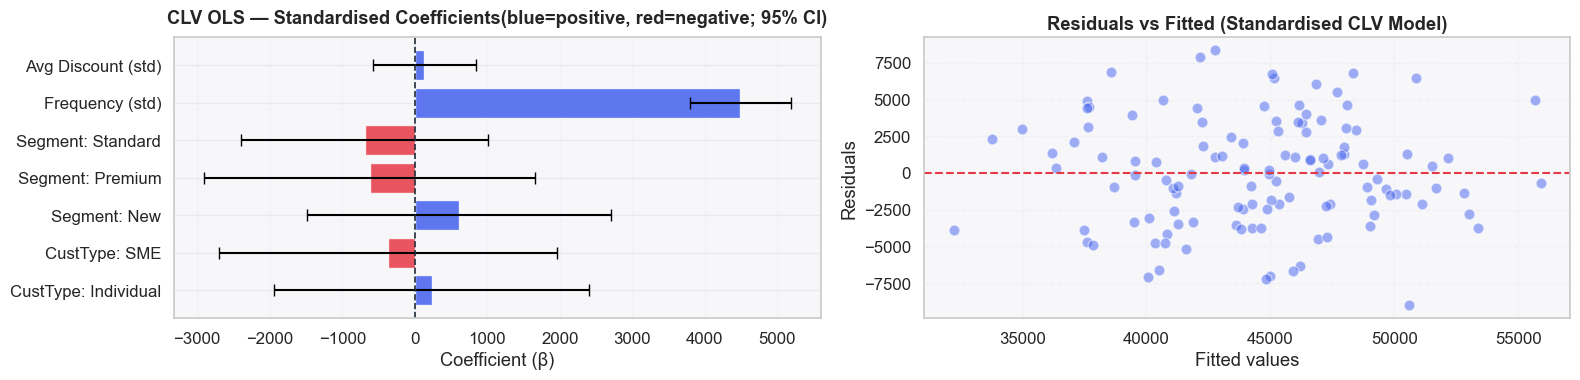

──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
ORIGINAL CLV OLS: coefficients are in dollars per unit (frequency count, discount %, etc.).
  → Useful for asking: if a customer buys 1 more time, how much more are they worth?

STANDARDISED CLV OLS: frequency and discount_percentage are z-scored.
  → Their coefficients now answer: which has MORE impact on lifetime value?
  → Frequency (std) vs Avg Discount (std) — the bigger |β|, the stronger driver.
  → Dummies (customer_type, segment) are already 0/1 — not scaled.

COEFFICIENT PLOT: bars that don't cross zero are statistically significant.
  → Compare bar lengths across ALL predictors to rank their importance.
  → If Frequency (std) >> Discount (std), driving repeat visits matters more
    than optimising discount strategy for increasing customer lifetime value.


In [110]:
if 'customer_type' in customers.columns:
    # ── Build customer-level dataset ──────────────────────────────────────────
    cust_val_df = rfm.merge(df[['customer_id', 'customer_type', 'segment']].drop_duplicates(), on='customer_id', how='left')
    avg_disc = df.groupby('customer_id')['discount_percentage'].mean().reset_index()
    cust_val_df = cust_val_df.merge(avg_disc, on='customer_id', how='left')

    try:
        # ── Original CLV OLS ──────────────────────────────────────────────────
        formula_clv = "monetary ~ frequency + discount_percentage + C(customer_type) + C(segment)"
        model_clv = smf_ols(formula_clv, data=cust_val_df).fit()
        print("═" * 70)
        print("  ORIGINAL CLV OLS — continuous predictors in natural units")
        print("═" * 70)
        print(model_clv.summary())

        # ── Standardised CLV OLS ──────────────────────────────────────────────
        # Z-score continuous predictors: frequency and discount_percentage
        clv_std = cust_val_df.copy()
        cont_clv = ['frequency', 'discount_percentage']
        for v in cont_clv:
            m, s = clv_std[v].mean(), clv_std[v].std()
            clv_std[v] = (clv_std[v] - m) / s
            print(f"  {v}: mean={m:.4f}, SD={s:.4f}  → z-scored")

        model_clv_std = smf_ols(formula_clv, data=clv_std).fit()
        print(" " + "═" * 70)
        print("  STANDARDISED CLV OLS — continuous predictors z-scored")
        print("  β = change in total customer revenue per 1 SD increase in predictor")
        print("═" * 70)
        print(model_clv_std.summary())

        # ── Standardised coefficient plot ─────────────────────────────────────
        coef_clv  = model_clv_std.params.drop('Intercept', errors='ignore')
        err_clv   = model_clv_std.bse.drop('Intercept', errors='ignore')

        labels_clv = [c.replace('C(customer_type)[T.', 'CustType: ').replace(']', '')
                       .replace('C(segment)[T.', 'Segment: ')
                       .replace('discount_percentage', 'Avg Discount (std)')
                       .replace('frequency', 'Frequency (std)')
                      for c in coef_clv.index]

        fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(coef_clv) * 0.45)))

        # Coefficient plot
        ax = axes[0]
        colors_clv = [COLORS['secondary'] if v < 0 else COLORS['primary'] for v in coef_clv.values]
        ax.barh(labels_clv, coef_clv.values, xerr=1.96 * err_clv.values,
                color=colors_clv, alpha=0.85, edgecolor='white', capsize=4)
        ax.axvline(0, color='#1F2937', linewidth=1.2, linestyle='--')
        ax.set_xlabel('Coefficient (β)')
        ax.set_title('CLV OLS — Standardised Coefficients(blue=positive, red=negative; 95% CI)', pad=10)
        ax.grid(axis='x', linestyle='--', alpha=0.4)

        # Residuals vs Fitted
        axes[1].scatter(model_clv_std.fittedvalues, model_clv_std.resid,
                        alpha=0.5, color=COLORS['primary'], edgecolors='white', s=60)
        axes[1].axhline(0, color=COLORS['secondary'], linewidth=1.5, linestyle='--')
        axes[1].set_xlabel('Fitted values')
        axes[1].set_ylabel('Residuals')
        axes[1].set_title('Residuals vs Fitted (Standardised CLV Model)')
        axes[1].grid(linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error in CLV regression: {e}")

print('' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print("ORIGINAL CLV OLS: coefficients are in dollars per unit (frequency count, discount %, etc.).")
print("  → Useful for asking: if a customer buys 1 more time, how much more are they worth?")
print("")
print("STANDARDISED CLV OLS: frequency and discount_percentage are z-scored.")
print("  → Their coefficients now answer: which has MORE impact on lifetime value?")
print("  → Frequency (std) vs Avg Discount (std) — the bigger |β|, the stronger driver.")
print("  → Dummies (customer_type, segment) are already 0/1 — not scaled.")
print("")
print("COEFFICIENT PLOT: bars that don't cross zero are statistically significant.")
print("  → Compare bar lengths across ALL predictors to rank their importance.")
print("  → If Frequency (std) >> Discount (std), driving repeat visits matters more")
print("    than optimising discount strategy for increasing customer lifetime value.")

## 3.5 ANOVA: Mean Revenue Across Branches

Are the differences in average revenue across our branches statistically significant, or just random noise? We use a one-way ANOVA test to find out.

ANOVA F-statistic: 0.47, p-value: 7.5556e-01


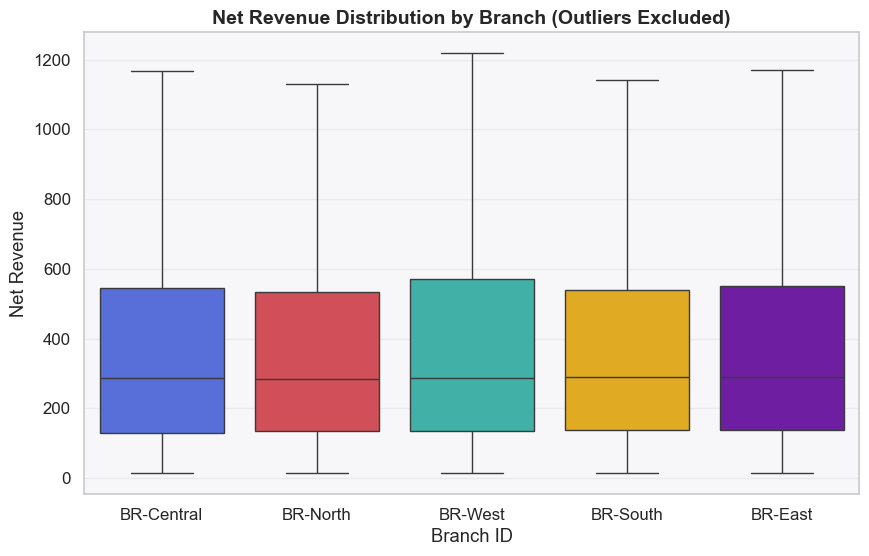


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The ANOVA test returned a p-value of 7.5556e-01.
If p < 0.05, we reject the null hypothesis; there is a statistically significant difference in mean revenue between AT LEAST TWO branches.
The boxplot visualizes these differences. If the ANOVA was significant, the Tukey HSD output tells us exactly *which* specific branches are different from each other.
Business Implication: If 'Branch A' significantly outperforms 'Branch B', management must investigate Branch A's practices (staffing, inventory, local marketing) to apply best practices across the network.


In [111]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Group data
branches = df['branch_id'].unique()
data_groups = [df[df['branch_id'] == b]['net_revenue'] for b in branches]

# Perform ANOVA
f_stat, p_val = stats.f_oneway(*data_groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_val:.4e}")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='branch_id', y='net_revenue', palette=COLORS['category_palette'], showfliers=False)
plt.title('Net Revenue Distribution by Branch (Outliers Excluded)', fontsize=14)
plt.xlabel('Branch ID')
plt.ylabel('Net Revenue')
plt.show()

# Tukey HSD if significant
if p_val < 0.05:
    print("ANOVA is significant. Performing Tukey HSD post-hoc test to find which pairs differ:")
    tukey = pairwise_tukeyhsd(endog=df['net_revenue'], groups=df['branch_id'], alpha=0.05)
    print(tukey)

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"The ANOVA test returned a p-value of {p_val:.4e}.")
print("If p < 0.05, we reject the null hypothesis; there is a statistically significant difference in mean revenue between AT LEAST TWO branches.")
print("The boxplot visualizes these differences. If the ANOVA was significant, the Tukey HSD output tells us exactly *which* specific branches are different from each other.")
print("Business Implication: If 'Branch A' significantly outperforms 'Branch B', management must investigate Branch A's practices (staffing, inventory, local marketing) to apply best practices across the network.")

## 3.6 Chi-Square Test: Payment Default Risk by Segment

Is late payment associated with specific customer types? We use a Chi-Square test of independence to see if payment status is dependent on customer segmentation.

Chi-Square Statistic: 988.16
P-value: 3.2494e-210
Cramér's V (Effect Size): 0.1955



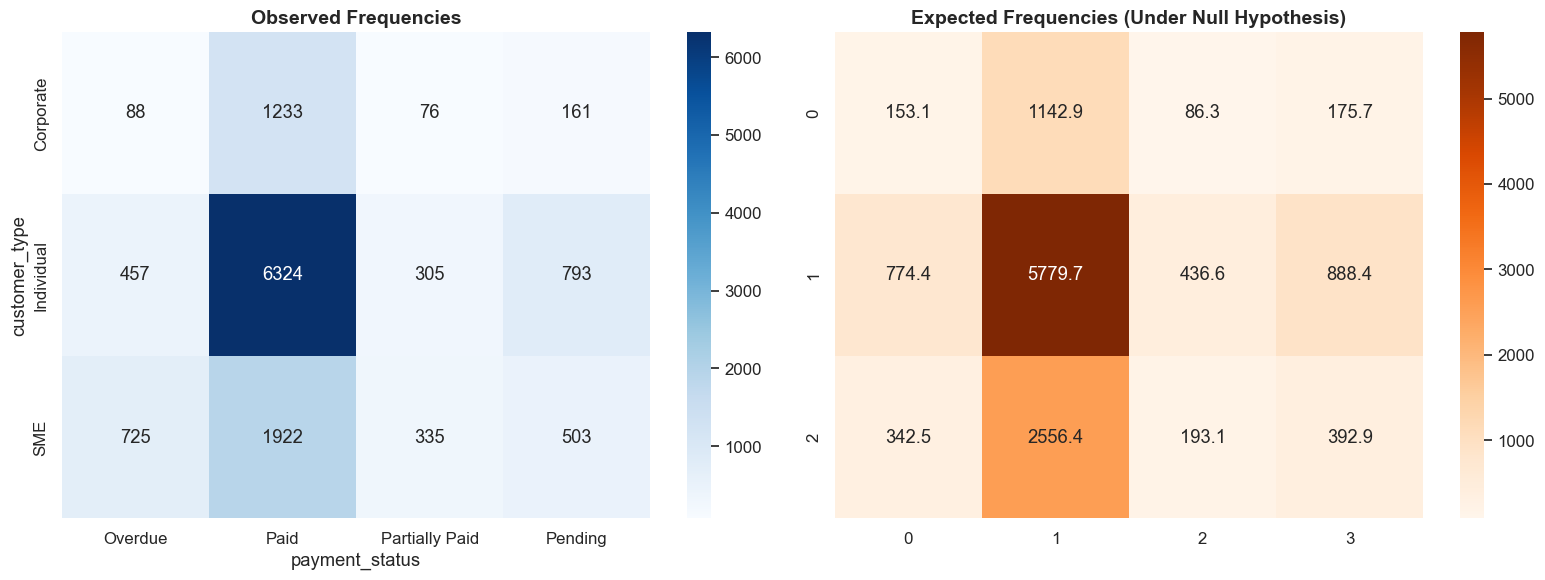


──────────────────────────────────────────────────────────────────────
📊 INTERPRETATION
──────────────────────────────────────────────────────────────────────
The Chi-Square test (p=3.2494e-210) evaluates if payment status and customer type are independent.
If p < 0.05, they are dependent. Cramér's V measures the strength of this association (0 to 1).
Comparing the Observed vs. Expected heatmaps shows exactly where the deviations occur.
Risk Implications: If 'SME' has a much higher observed 'Overdue' count than expected, credit policies for SMEs need tightening.


In [112]:
if 'customer_type' in customers.columns and 'payment_status' in df.columns:
    # Contingency Table
    contingency_table = pd.crosstab(df['customer_type'], df['payment_status'])
    
    # Chi-Square Test
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    
    # Cramér's V for effect size
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramer_v = np.sqrt(chi2 / (n * min_dim))
    
    print(f"Chi-Square Statistic: {chi2:.2f}")
    print(f"P-value: {p:.4e}")
    print(f"Cramér's V (Effect Size): {cramer_v:.4f}\n")
    
    # Plot Observed vs Expected Heatmap
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Observed Frequencies', fontsize=14)
    
    sns.heatmap(expected, annot=True, fmt='.1f', cmap='Oranges', ax=ax[1])
    ax[1].set_title('Expected Frequencies (Under Null Hypothesis)', fontsize=14)
    
    plt.tight_layout()
    plt.show()

print('\n' + '─'*70)
print('📊 INTERPRETATION')
print('─'*70)
print(f"The Chi-Square test (p={p:.4e}) evaluates if payment status and customer type are independent.")
print("If p < 0.05, they are dependent. Cramér's V measures the strength of this association (0 to 1).")
print("Comparing the Observed vs. Expected heatmaps shows exactly where the deviations occur.")
print("Risk Implications: If 'SME' has a much higher observed 'Overdue' count than expected, credit policies for SMEs need tightening.")